# Avance 1 — Análisis Exploratorio de Datos

## Generalización de modelos nacionales de pronóstico epidemiológico hacia un enfoque modular con desagregación por sexo y entidad federativa en México

**Proyecto:** EpiForecast-MX  
**Curso:** TC5035.10 — Proyecto Integrador  
**Programa:** Maestría en Inteligencia Artificial Aplicada  
**Institución:** Tecnológico de Monterrey

---

| Matrícula | Estudiante |
|-----------|-----------|
| A01795838 | Javier Augusto Rebull Saucedo |
| A01795941 | Juan Carlos Pérez Nava |
| A01232963 | Luis Gerardo Sánchez Salazar |

**Equipo docente:**
- Dra. Grettel Barceló Alonso — Profesora Titular y Asesora del Proyecto
- Dr. Luis Eduardo Falcón Morales — Director Nacional de MNA
- Mtra. Verónica Sandra Guzmán de Valle — Profesora Asistente

**Patrocinador:**
- Dra. Ruth Pérez-Hernández — Líder del Proyecto IMSS
- Dra. Lina Díaz Castro — Investigadora en Psiquiatría

---
# 1. Setup y Configuración

Importaciones, constantes globales y funciones auxiliares reutilizables para todo el análisis.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
from pathlib import Path
from datetime import datetime
from typing import Optional
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import gaussian_kde, skew, kurtosis
from loguru import logger
import sys

warnings.filterwarnings("ignore", category=FutureWarning)
logger.remove()
logger.add(sys.stderr, level="INFO", format="{time:HH:mm:ss} | {level:<7} | {message}")
logger.info("EDA Avance 1 — EpiForecast-MX inicializado")

21:26:34 | INFO    | EDA Avance 1 — EpiForecast-MX inicializado


In [2]:
# =============================================================================
# CONSTANTES Y CONFIGURACIÓN
# =============================================================================

# --- Rutas -------------------------------------------------------------------
DATA_PATH = Path("../data/processed/dataset_boletin_epidemiologico.csv")
OUTPUT_PATH = Path("../outputs/eda")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# --- Semilla para reproducibilidad -------------------------------------------
SEED = 42
np.random.seed(SEED)

# --- Paleta IMSS institucional (Guía cromática oficial) ----------------------
IMSS_COLORS = {
    "neutral_black":  "#231F20",  # PANTONE Neutral Black C
    "burgundy":       "#9B2242",  # PANTONE 7420 C
    "dark_burgundy":  "#6F1D46",  # PANTONE 7421 C
    "cool_gray":      "#97999B",  # PANTONE Cool Gray C
    "teal":           "#00524E",  # PANTONE IMSS 561 C
    "dark_teal":      "#173F35",  # PANTONE 627 C
    "cream":          "#E8D5B5",  # PANTONE 7402 C
    "gold":           "#B58500",  # PANTONE 1255 C
}

# Paleta secuencial para gráficos
PALETTE_MAIN = [
    IMSS_COLORS["teal"],
    IMSS_COLORS["burgundy"],
    IMSS_COLORS["gold"],
    IMSS_COLORS["dark_teal"],
    IMSS_COLORS["dark_burgundy"],
    IMSS_COLORS["cool_gray"],
    IMSS_COLORS["neutral_black"],
    IMSS_COLORS["cream"],
]

PALETTE_PADECIMIENTO = {
    "Depresión":  IMSS_COLORS["burgundy"],
    "Parkinson":  IMSS_COLORS["teal"],
    "Alzheimer":  IMSS_COLORS["gold"],
}

PALETTE_SEXO = {
    "Hombres": IMSS_COLORS["teal"],
    "Mujeres": IMSS_COLORS["burgundy"],
}

# --- Estilo global de matplotlib ---------------------------------------------
plt.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.edgecolor":      IMSS_COLORS["cool_gray"],
    "axes.labelcolor":     IMSS_COLORS["neutral_black"],
    "text.color":          IMSS_COLORS["neutral_black"],
    "xtick.color":         IMSS_COLORS["neutral_black"],
    "ytick.color":         IMSS_COLORS["neutral_black"],
    "axes.grid":           True,
    "grid.alpha":          0.3,
    "grid.color":          IMSS_COLORS["cool_gray"],
    "font.family":         "sans-serif",
    "font.size":           11,
    "axes.titlesize":      13,
    "axes.titleweight":    "bold",
    "figure.titlesize":    15,
    "figure.titleweight":  "bold",
    "figure.dpi":          120,
    "savefig.dpi":         150,
    "savefig.bbox":        "tight",
})

# --- Variables del dataset ---------------------------------------------------
COLS_NUMERICAS = ["Anio", "Semana", "Casos_semana", "Acumulado_hombres",
                  "Acumulado_mujeres", "Acumulado_anio_anterior"]
COLS_CATEGORICAS = ["Entidad", "Padecimiento"]
PADECIMIENTOS = ["Depresión", "Parkinson", "Alzheimer"]
NUM_ENTIDADES = 32

logger.success(f"Configuración cargada | Paleta IMSS: {len(IMSS_COLORS)} colores")

21:26:38 | SUCCESS | Configuración cargada | Paleta IMSS: 8 colores


In [3]:
# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================

def cargar_datos(ruta: Path) -> pd.DataFrame:
    """Carga el dataset y realiza validaciones iniciales.

    Parameters
    ----------
    ruta : Path
        Ruta al archivo CSV.

    Returns
    -------
    pd.DataFrame
        DataFrame con los datos cargados.
    """
    if not ruta.exists():
        raise FileNotFoundError(f"Dataset no encontrado en: {ruta.resolve()}")
    df = pd.read_csv(ruta)
    logger.info(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    return df


def resumen_dataframe(df: pd.DataFrame, titulo: str = "Dataset") -> pd.DataFrame:
    """Genera un resumen compacto de un DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame a resumir.
    titulo : str
        Titulo descriptivo para el resumen.

    Returns
    -------
    pd.DataFrame
        Tabla resumen con metricas clave.
    """
    resumen = pd.DataFrame({
        "Metrica": [
            "Filas", "Columnas", "Columnas numericas",
            "Columnas categoricas", "% valores nulos",
            "Duplicados exactos", "Memoria (MB)"
        ],
        "Valor": [
            f"{df.shape[0]:,}",
            f"{df.shape[1]}",
            f"{df.select_dtypes(include='number').shape[1]}",
            f"{df.select_dtypes(include=['object', 'category']).shape[1]}",
            f"{df.isna().mean().mean() * 100:.2f}%",
            f"{df.duplicated().sum():,}",
            f"{df.memory_usage(deep=True).sum() / 1e6:.2f}",
        ]
    })
    logger.info(f"Resumen '{titulo}': {df.shape[0]:,} x {df.shape[1]}")
    return resumen


def tabla_nulos(df: pd.DataFrame) -> pd.DataFrame:
    """Genera tabla de valores nulos por columna."""
    nulos = df.isna().sum()
    porcentaje = (df.isna().mean() * 100).round(2)
    tabla = pd.DataFrame({
        "Nulos": nulos,
        "% Nulos": porcentaje,
        "Tipo": df.dtypes.astype(str)
    }).sort_values("Nulos", ascending=False)
    return tabla[tabla["Nulos"] > 0]


def tabla_valores_unicos(df: pd.DataFrame) -> pd.DataFrame:
    """Genera tabla de valores unicos por columna."""
    return pd.DataFrame({
        "Valores unicos": df.nunique(dropna=True),
        "Tipo": df.dtypes.astype(str)
    }).sort_values("Valores unicos", ascending=False)


def guardar_figura(fig: plt.Figure, nombre: str) -> None:
    """Guarda una figura en la carpeta de outputs."""
    ruta = OUTPUT_PATH / f"{nombre}.png"
    fig.savefig(ruta, bbox_inches="tight", facecolor="white")
    logger.debug(f"Figura guardada: {ruta}")


def format_axis(ax: plt.Axes, titulo: str = "", xlabel: str = "",
                ylabel: str = "", rotation_x: int = 0) -> None:
    """Aplica formato consistente a un eje de matplotlib."""
    if titulo:
        ax.set_title(titulo, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if rotation_x:
        ax.tick_params(axis="x", rotation=rotation_x)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Definicion de regiones de Mexico
REGIONES = {
    "Norte": ["Baja California", "Baja California Sur", "Chihuahua", "Coahuila",
              "Durango", "Nuevo Leon", "Sinaloa", "Sonora", "Tamaulipas"],
    "Occidente": ["Aguascalientes", "Colima", "Guanajuato", "Jalisco", "Michoacan",
                  "Nayarit", "San Luis Potosi", "Zacatecas"],
    "Centro": ["Ciudad de Mexico", "Distrito Federal", "Hidalgo", "Mexico",
               "Morelos", "Puebla", "Queretaro", "Tlaxcala"],
    "Sureste": ["Campeche", "Chiapas", "Guerrero", "Oaxaca", "Quintana Roo",
                "Tabasco", "Veracruz", "Yucatan"],
}

def asignar_region(entidad: str) -> str:
    """Asigna una region a una entidad federativa."""
    for region, entidades in REGIONES.items():
        if entidad in entidades:
            return region
    return "Sin region"


logger.success("Funciones auxiliares definidas")

21:26:46 | SUCCESS | Funciones auxiliares definidas


---
# 2. Carga de Datos

El dataset se obtiene mediante DVC (`dvc pull`) y se encuentra en `data/processed/dataset_boletin_epidemiologico.csv`. Contiene registros semanales de casos de Depresión (F32), Parkinson (G20) y Alzheimer (G30) extraídos de los Boletines Epidemiológicos del SINAVE (2012–2025), desglosados por entidad federativa y sexo.

In [4]:
# =============================================================================
# CARGA Y PRIMERA INSPECCION
# =============================================================================
df_raw = cargar_datos(DATA_PATH)
display(df_raw.head(10))

21:26:55 | INFO    | Dataset cargado: 60,288 filas x 8 columnas


,Anio,Semana,Entidad,Padecimiento,Casos_semana,Acumulado_hombres,Acumulado_mujeres,Acumulado_anio_anterior
0,2014,2,Aguascalientes,Depresión,1.0,1,0,NaN
1,2014,2,Aguascalientes,Parkinson,0.0,0,0,NaN
2,2014,2,Aguascalientes,Alzheimer,0.0,0,0,NaN
3,2014,2,Baja California,Depresión,2.0,1,1,NaN
4,2014,2,Baja California,Parkinson,1.0,1,0,NaN
5,2014,2,Baja California,Alzheimer,0.0,0,0,NaN
6,2014,2,Baja California Sur,Depresión,0.0,0,0,NaN
7,2014,2,Baja California Sur,Parkinson,0.0,0,0,NaN
8,2014,2,Baja California Sur,Alzheimer,0.0,0,0,NaN
9,2014,2,Campeche,Depresión,2.0,1,1,NaN


In [11]:
display(df_raw.tail(10))

,Anio,Semana,Entidad,Padecimiento,Casos_semana,Acumulado_hombres,Acumulado_mujeres,Acumulado_anio_anterior
60278,2026,2,Tlaxcala,Alzheimer,0.0,0,0,0.0
60279,2026,2,Veracruz,Depresión,92.0,27,65,42.0
60280,2026,2,Veracruz,Parkinson,16.0,5,11,9.0
60281,2026,2,Veracruz,Alzheimer,2.0,0,2,1.0
60282,2026,2,Yucatán,Depresión,87.0,27,60,31.0
60283,2026,2,Yucatán,Parkinson,8.0,3,5,2.0
60284,2026,2,Yucatán,Alzheimer,0.0,0,0,0.0
60285,2026,2,Zacatecas,Depresión,64.0,19,45,38.0
60286,2026,2,Zacatecas,Parkinson,2.0,1,1,0.0
60287,2026,2,Zacatecas,Alzheimer,0.0,0,0,0.0


In [5]:
# Tipos de datos e informacion general
print("=" * 60)
print("INFORMACION DEL DATASET")
print("=" * 60)
df_raw.info()

INFORMACION DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60288 entries, 0 to 60287
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Anio                     60288 non-null  int64  
 1   Semana                   60288 non-null  int64  
 2   Entidad                  60288 non-null  object 
 3   Padecimiento             60288 non-null  object 
 4   Casos_semana             60285 non-null  float64
 5   Acumulado_hombres        60288 non-null  int64  
 6   Acumulado_mujeres        60288 non-null  int64  
 7   Acumulado_anio_anterior  55200 non-null  float64
dtypes: float64(2), int64(4), object(2)
memory usage: 3.7+ MB


In [6]:
# Resumen general
resumen = resumen_dataframe(df_raw, "Dataset Crudo")
display(resumen.style.set_caption("Resumen general del dataset").hide(axis="index"))

21:27:09 | INFO    | Resumen 'Dataset Crudo': 60,288 x 8


Metrica,Valor
Filas,"60,288"
Columnas,8
Columnas numericas,6
Columnas categoricas,2
% valores nulos,1.06%
Duplicados exactos,0
Memoria (MB),10.79


---
# 3. Análisis de Calidad de Datos

Evaluación de completitud, consistencia y confiabilidad del dataset crudo.

## 3.1 Valores Faltantes

In [7]:
# =============================================================================
# 3.1 VALORES FALTANTES
# =============================================================================
df_nulos = tabla_nulos(df_raw)
display(df_nulos.style.set_caption("Columnas con valores nulos"))

total_nulos = df_raw.isna().sum().sum()
total_celdas = df_raw.shape[0] * df_raw.shape[1]
pct_total = total_nulos / total_celdas * 100
logger.info(f"Total de valores nulos: {total_nulos:,} de {total_celdas:,} ({pct_total:.2f}%)")

,Nulos,% Nulos,Tipo
Acumulado_anio_anterior,5088,8.440000,float64
Casos_semana,3,0.000000,float64


21:27:19 | INFO    | Total de valores nulos: 5,091 de 482,304 (1.06%)


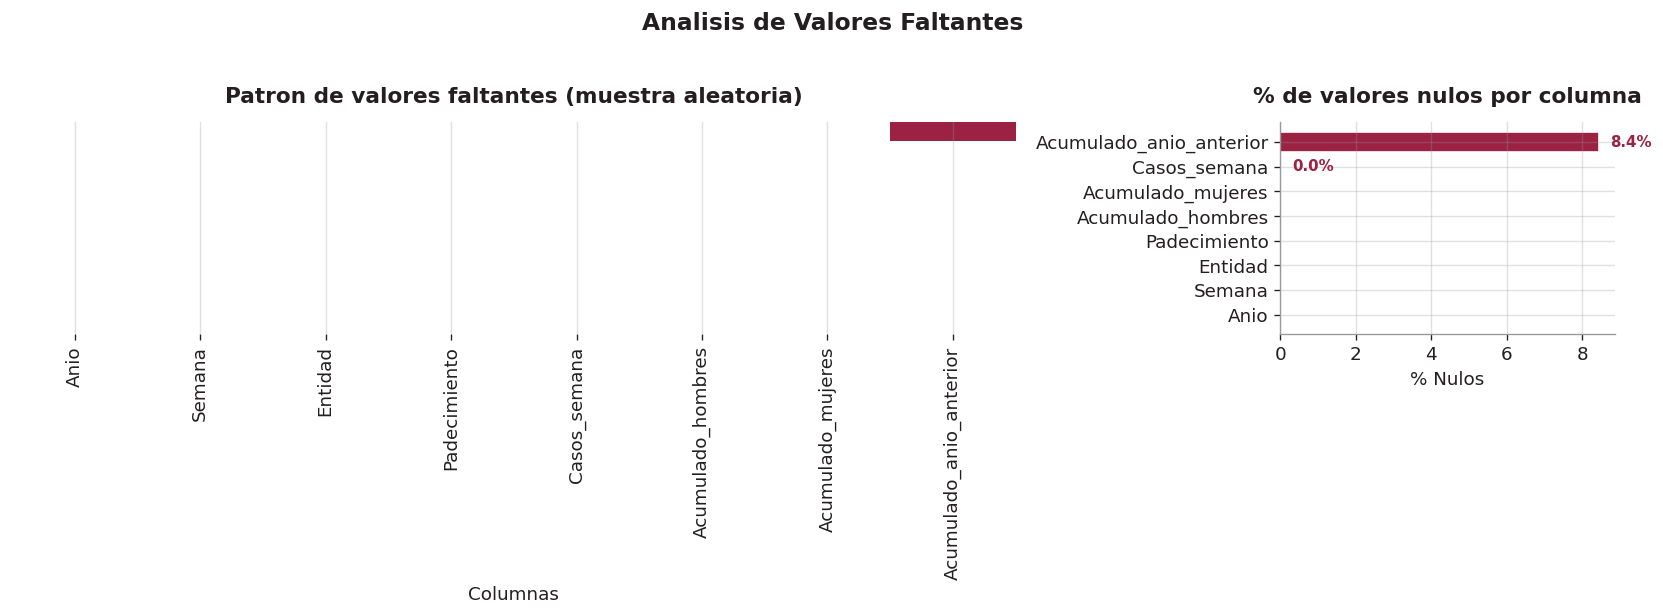

In [8]:
# --- Visualizacion: mapa de nulos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 1]})

# Mapa de calor de nulos (muestra aleatoria para rendimiento)
sample_size = min(2000, len(df_raw))
sample_idx = np.random.choice(df_raw.index, sample_size, replace=False)
sample_sorted = sorted(sample_idx)

ax = axes[0]
sns.heatmap(
    df_raw.loc[sample_sorted].isna().astype(int),
    cbar=False, cmap=["white", IMSS_COLORS["burgundy"]],
    yticklabels=False, ax=ax
)
format_axis(ax, titulo="Patron de valores faltantes (muestra aleatoria)")
ax.set_xlabel("Columnas")

# Barras de porcentaje de nulos
ax2 = axes[1]
pct_nulos = (df_raw.isna().mean() * 100).sort_values(ascending=True)
colores = [IMSS_COLORS["burgundy"] if v > 0 else IMSS_COLORS["cool_gray"] for v in pct_nulos.values]
ax2.barh(pct_nulos.index, pct_nulos.values, color=colores, edgecolor="white")
for i, (col, val) in enumerate(pct_nulos.items()):
    if val > 0:
        ax2.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9,
                 color=IMSS_COLORS["burgundy"], fontweight="bold")
format_axis(ax2, titulo="% de valores nulos por columna", xlabel="% Nulos")

fig.suptitle("Analisis de Valores Faltantes", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
guardar_figura(fig, "01_valores_faltantes")
plt.show()

In [12]:
# --- Analisis del patron de ausencia (MCAR / MAR / MNAR) ---
print("=" * 60)
print("ANALISIS DEL PATRON DE AUSENCIA")
print("=" * 60)

if "Acumulado_anio_anterior" in df_raw.columns:
    nulos_por_anio = (
        df_raw[df_raw["Acumulado_anio_anterior"].isna()]
        .groupby("Anio").size()
        .reindex(df_raw["Anio"].unique(), fill_value=0)
        .sort_index()
    )
    print("\nNulos en 'Acumulado_anio_anterior' por anio:")
    display(nulos_por_anio.to_frame("Nulos").T)
    
    print("\n-> Los nulos se concentran en el primer anio de registro (sin anio anterior disponible).")
    print("   Patron identificado: MAR (Missing At Random) - condicionado al anio.")

if "Casos_semana" in df_raw.columns:
    nulos_cs = df_raw["Casos_semana"].isna().sum()
    if nulos_cs > 0:
        print(f"\nNulos en 'Casos_semana': {nulos_cs} registros (marginal)")
        print("   Patron: posible MCAR - registros aislados sin patron identificable.")

ANALISIS DEL PATRON DE AUSENCIA

Nulos en 'Acumulado_anio_anterior' por anio:


Anio,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Nulos,4992,96,0,0,0,0,0,0,0,0,0,0,0



-> Los nulos se concentran en el primer anio de registro (sin anio anterior disponible).
   Patron identificado: MAR (Missing At Random) - condicionado al anio.

Nulos en 'Casos_semana': 3 registros (marginal)
   Patron: posible MCAR - registros aislados sin patron identificable.


## 3.2 Duplicados e Inconsistencias

In [13]:
# =============================================================================
# 3.2 DUPLICADOS E INCONSISTENCIAS
# =============================================================================
print("=" * 60)
print("ANALISIS DE DUPLICADOS")
print("=" * 60)

duplicados_exactos = df_raw.duplicated().sum()
print(f"Duplicados exactos: {duplicados_exactos:,}")

clave = ["Anio", "Semana", "Entidad", "Padecimiento"]
duplicados_clave = df_raw.duplicated(subset=clave, keep=False).sum()
print(f"Registros con clave duplicada ({' + '.join(clave)}): {duplicados_clave:,}")

if duplicados_clave > 0:
    print("\nEjemplo de duplicados por clave natural:")
    display(df_raw[df_raw.duplicated(subset=clave, keep=False)].head(10))
else:
    print("-> No hay duplicados por clave natural.")

ANALISIS DE DUPLICADOS
Duplicados exactos: 0
Registros con clave duplicada (Anio + Semana + Entidad + Padecimiento): 0
-> No hay duplicados por clave natural.


In [14]:
# --- Validacion de rangos e inconsistencias ---
print("=" * 60)
print("VALIDACION DE RANGOS Y CONSISTENCIA")
print("=" * 60)

print(f"\nRango de anios: {df_raw['Anio'].min()} - {df_raw['Anio'].max()}")
print(f"Anios unicos: {sorted(df_raw['Anio'].unique())}")

semanas_unicas = sorted(df_raw['Semana'].unique())
print(f"\nRango de semanas: {df_raw['Semana'].min()} - {df_raw['Semana'].max()}")
print(f"Semanas unicas ({len(semanas_unicas)}): {semanas_unicas}")
if len(semanas_unicas) > 52:
    print("!! Se detectan mas de 52 semanas - revisar semana 53 (anio 2020)")

entidades = sorted(df_raw["Entidad"].unique())
print(f"\nEntidades unicas ({len(entidades)}):")
for e in entidades:
    print(f"  - {e}")

if len(entidades) != NUM_ENTIDADES:
    print(f"\n!! Se esperan {NUM_ENTIDADES} entidades, se encontraron {len(entidades)}.")
    print("   -> Posible causa: 'Distrito Federal' y 'Ciudad de Mexico' como entradas separadas.")

print(f"\nPadecimientos: {sorted(df_raw['Padecimiento'].unique())}")

for col in ["Casos_semana", "Acumulado_hombres", "Acumulado_mujeres", "Acumulado_anio_anterior"]:
    if col in df_raw.columns:
        negativos = (df_raw[col] < 0).sum()
        if negativos > 0:
            print(f"\n!! {col}: {negativos} valores negativos detectados")

VALIDACION DE RANGOS Y CONSISTENCIA

Rango de anios: 2014 - 2026
Anios unicos: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Rango de semanas: 1 - 53
Semanas unicas (53): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), n

## 3.3 Valores Únicos

In [16]:
df_unicos = tabla_valores_unicos(df_raw)
display(df_unicos.style.set_caption("Valores unicos por columna"))

,Valores unicos,Tipo
Acumulado_anio_anterior,5171,float64
Acumulado_mujeres,4545,int64
Acumulado_hombres,2393,int64
Casos_semana,507,float64
Semana,53,int64
Entidad,33,object
Anio,13,int64
Padecimiento,3,object


---
# 4. Estadísticas Descriptivas

Resumen estadístico extendido de las variables numéricas y categóricas.

## 4.1 Variables Numéricas

In [17]:
# =============================================================================
# 4.1 ESTADISTICAS NUMERICAS EXTENDIDAS
# =============================================================================
num = df_raw.select_dtypes(include="number")
desc_basico = num.describe().T.round(2)
display(desc_basico.style.set_caption("Estadisticas descriptivas - variables numericas"))

,count,mean,std,min,25%,50%,75%,max
Anio,60288.000000,2019.530000,3.470000,2014.000000,2017.000000,2020.000000,2023.000000,2026.000000
Semana,60288.000000,26.590000,15.100000,1.000000,13.750000,27.000000,40.000000,53.000000
Casos_semana,60285.000000,24.910000,52.760000,0.000000,1.000000,4.000000,26.000000,1311.000000
Acumulado_hombres,60288.000000,188.930000,439.730000,0.000000,10.000000,40.000000,165.000000,6671.000000
Acumulado_mujeres,60288.000000,492.090000,1223.060000,0.000000,13.000000,47.000000,379.000000,17782.000000
Acumulado_anio_anterior,55200.000000,668.170000,1625.790000,0.000000,24.000000,89.000000,530.250000,24017.000000


In [18]:
# --- Estadisticas extendidas: sesgo, curtosis, coeficiente de variacion ---
desc_extendido = pd.DataFrame({
    "media":    num.mean(),
    "mediana":  num.median(),
    "std":      num.std(),
    "sesgo":    num.apply(lambda x: skew(x.dropna())),
    "curtosis": num.apply(lambda x: kurtosis(x.dropna())),
    "CV (%)":   (num.std() / num.mean() * 100),
    "IQR":      num.quantile(0.75) - num.quantile(0.25),
    "min":      num.min(),
    "max":      num.max(),
}).round(2)

display(desc_extendido.style.set_caption(
    "Estadisticas extendidas (sesgo, curtosis, CV)"
).background_gradient(subset=["sesgo"], cmap="RdYlGn_r", vmin=-2, vmax=5))

print("\n-> Valores de sesgo > 1 indican asimetria positiva fuerte (cola derecha).")
print("   Las variables de casos y acumulados muestran distribuciones altamente sesgadas.")

,media,mediana,std,sesgo,curtosis,CV (%),IQR,min,max
Anio,2019.530000,2020.000000,3.470000,0.000000,-1.210000,0.170000,6.000000,2014.000000,2026.000000
Semana,26.590000,27.000000,15.100000,0.000000,-1.200000,56.810000,26.250000,1.000000,53.000000
Casos_semana,24.910000,4.000000,52.760000,4.550000,31.480000,211.810000,25.000000,0.000000,1311.000000
Acumulado_hombres,188.930000,40.000000,439.730000,5.790000,48.100000,232.740000,155.000000,0.000000,6671.000000
Acumulado_mujeres,492.090000,47.000000,1223.060000,5.530000,44.360000,248.550000,366.000000,0.000000,17782.000000
Acumulado_anio_anterior,668.170000,89.000000,1625.790000,5.540000,43.880000,243.320000,506.250000,0.000000,24017.000000



-> Valores de sesgo > 1 indican asimetria positiva fuerte (cola derecha).
   Las variables de casos y acumulados muestran distribuciones altamente sesgadas.


## 4.2 Variables Categóricas

In [19]:
# =============================================================================
# 4.2 ESTADISTICAS CATEGORICAS
# =============================================================================
cat = df_raw.select_dtypes(include=["object", "category"])

resumen_cat = []
for col in cat.columns:
    serie = cat[col]
    moda = serie.mode().iloc[0] if not serie.mode().empty else "N/A"
    freq_moda = serie.value_counts().iloc[0]
    resumen_cat.append({
        "Columna": col,
        "Conteo": serie.size,
        "Valores unicos": serie.nunique(),
        "Moda": moda,
        "Frecuencia moda": freq_moda,
        "% Moda": round(freq_moda / serie.size * 100, 2),
    })

display(
    pd.DataFrame(resumen_cat)
    .style.set_caption("Estadisticas descriptivas - variables categoricas")
    .hide(axis="index")
)

Columna,Conteo,Valores unicos,Moda,Frecuencia moda,% Moda
Entidad,60288,33,Aguascalientes,1884,3.120000
Padecimiento,60288,3,Alzheimer,20096,33.330000


In [20]:
# --- Frecuencias de cada variable categorica ---
for col in cat.columns:
    vc = cat[col].fillna("N/A").value_counts(dropna=False)
    print(f"\n{'='*50}")
    print(f"Frecuencias: {col} ({len(vc)} categorias)")
    print(f"{'='*50}")
    display(vc.to_frame("Frecuencia").assign(
        Porcentaje=lambda x: (x["Frecuencia"] / x["Frecuencia"].sum() * 100).round(2)
    ))


Frecuencias: Entidad (33 categorias)


,Frecuencia,Porcentaje
Entidad,,
Aguascalientes,1884,3.12
Nayarit,1884,3.12
Zacatecas,1884,3.12
Yucatán,1884,3.12
Veracruz,1884,3.12
Tlaxcala,1884,3.12
Tamaulipas,1884,3.12
Tabasco,1884,3.12
Sonora,1884,3.12



Frecuencias: Padecimiento (3 categorias)


,Frecuencia,Porcentaje
Padecimiento,,
Depresión,20096,33.33
Parkinson,20096,33.33
Alzheimer,20096,33.33


---
# 5. Análisis Univariante

Distribución individual de cada variable con histogramas, KDE, boxplots y gráficos de barras.

## 5.1 Distribución de Variables Numéricas

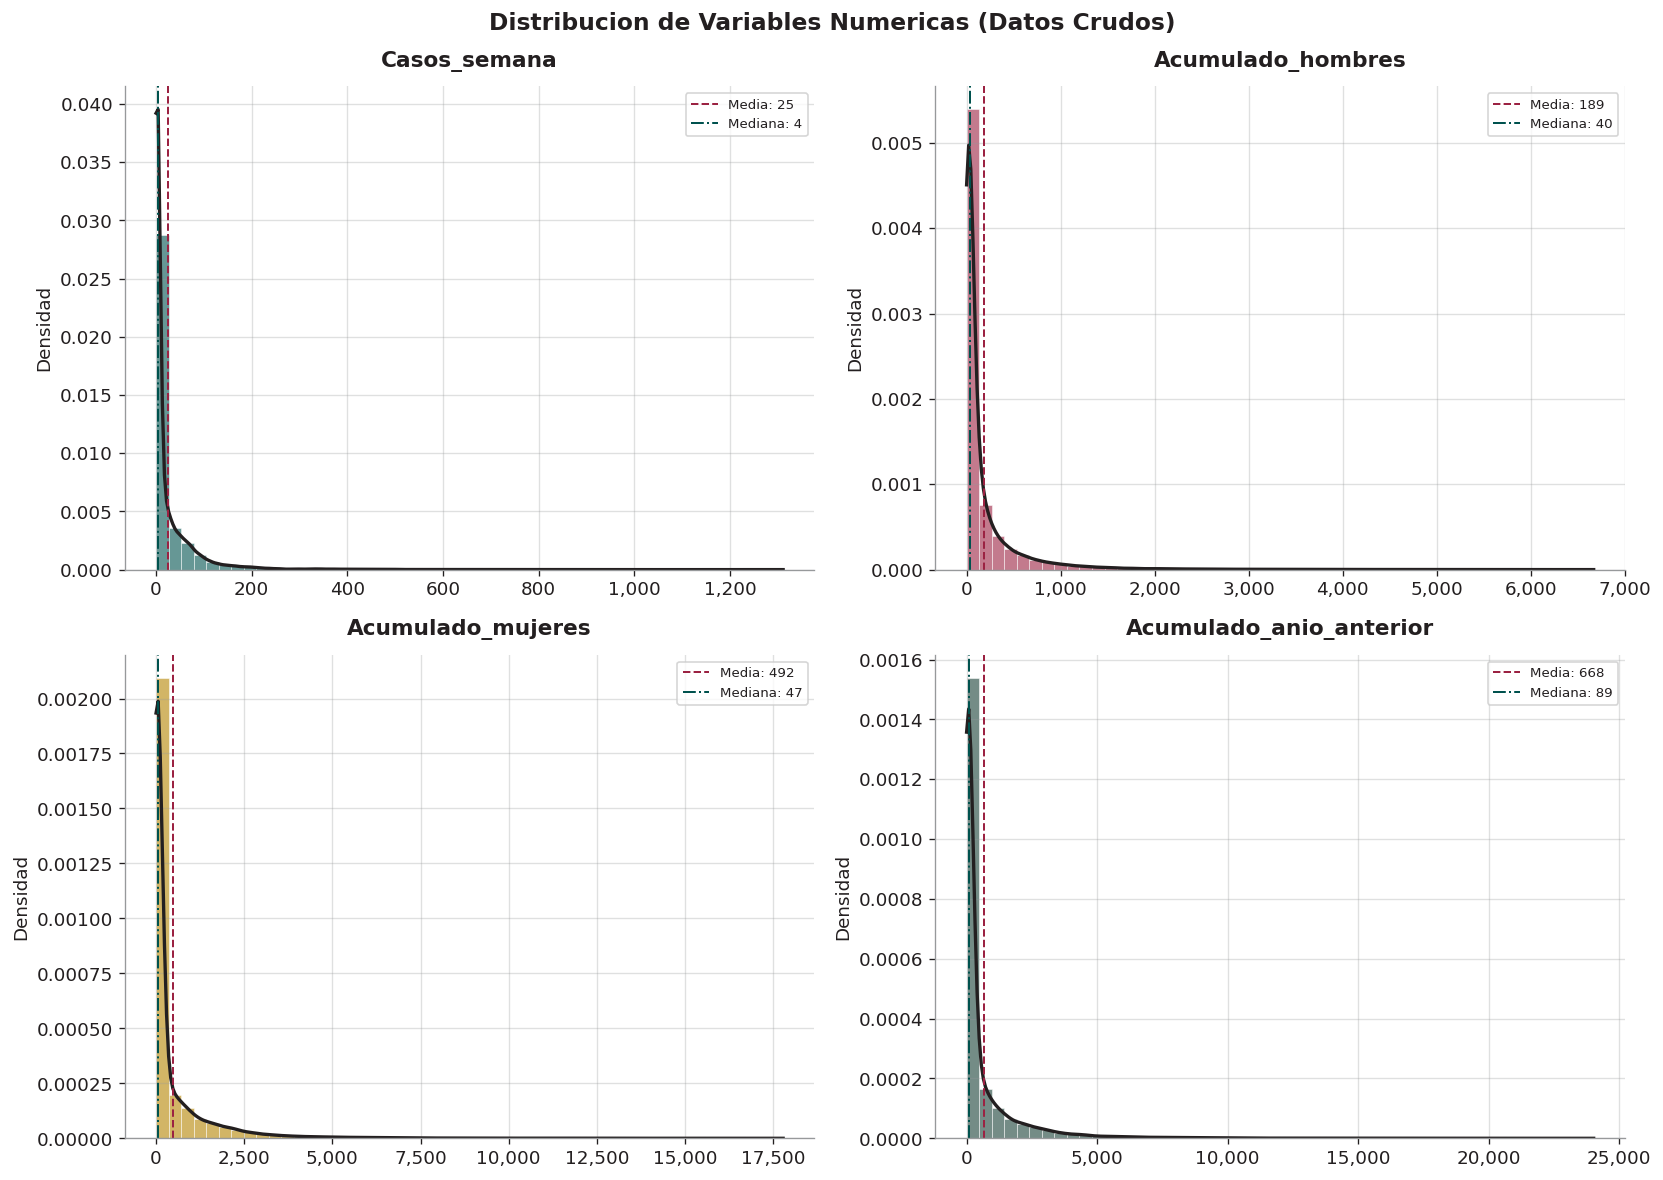

-> Todas las variables de casos/acumulados muestran asimetria positiva marcada.


In [21]:
# =============================================================================
# 5.1 HISTOGRAMAS + KDE DE VARIABLES NUMERICAS
# =============================================================================
num_cols = ["Casos_semana", "Acumulado_hombres", "Acumulado_mujeres", "Acumulado_anio_anterior"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    datos = df_raw[col].dropna()

    ax.hist(datos, bins=50, density=True, alpha=0.6,
            color=PALETTE_MAIN[i], edgecolor="white", linewidth=0.5)

    try:
        kde = gaussian_kde(datos)
        x_vals = np.linspace(datos.min(), datos.max(), 300)
        ax.plot(x_vals, kde(x_vals), color=IMSS_COLORS["neutral_black"], linewidth=2)
    except Exception:
        pass

    ax.axvline(datos.mean(), color=IMSS_COLORS["burgundy"], linestyle="--",
               linewidth=1.2, label=f"Media: {datos.mean():,.0f}")
    ax.axvline(datos.median(), color=IMSS_COLORS["teal"], linestyle="-.",
               linewidth=1.2, label=f"Mediana: {datos.median():,.0f}")

    format_axis(ax, titulo=col, ylabel="Densidad")
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle("Distribucion de Variables Numericas (Datos Crudos)", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "02_histogramas_numericas_raw")
plt.show()

print("-> Todas las variables de casos/acumulados muestran asimetria positiva marcada.")

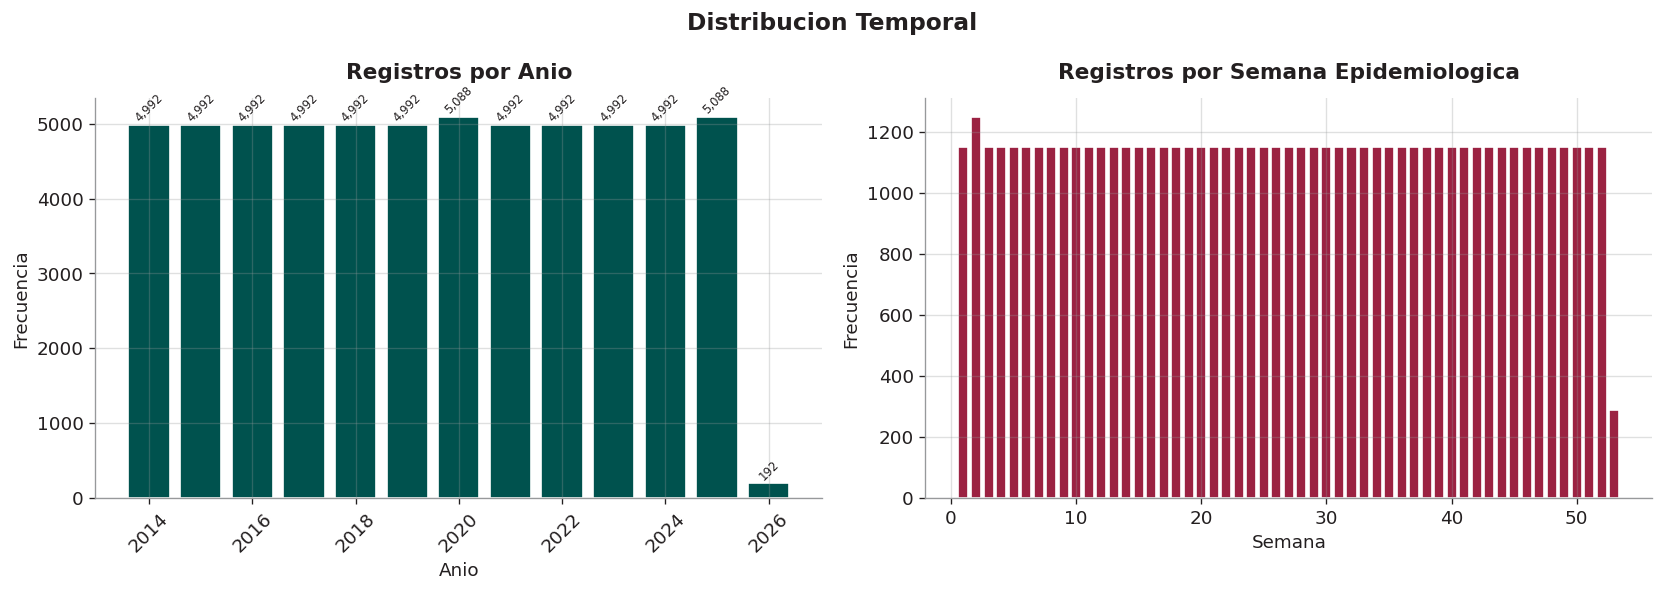

In [22]:
# =============================================================================
# HISTOGRAMAS DE ANIO Y SEMANA
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anio
ax = axes[0]
anio_counts = df_raw["Anio"].value_counts().sort_index()
ax.bar(anio_counts.index, anio_counts.values, color=IMSS_COLORS["teal"], edgecolor="white")
for x, y in zip(anio_counts.index, anio_counts.values):
    ax.text(x, y + 50, f"{y:,}", ha="center", fontsize=7, rotation=45)
format_axis(ax, titulo="Registros por Anio", xlabel="Anio", ylabel="Frecuencia", rotation_x=45)

# Semana
ax = axes[1]
semana_counts = df_raw["Semana"].value_counts().sort_index()
ax.bar(semana_counts.index, semana_counts.values, color=IMSS_COLORS["burgundy"], edgecolor="white")
format_axis(ax, titulo="Registros por Semana Epidemiologica", xlabel="Semana", ylabel="Frecuencia")

fig.suptitle("Distribucion Temporal", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "03_distribucion_temporal")
plt.show()

## 5.2 Boxplots de Variables Numéricas

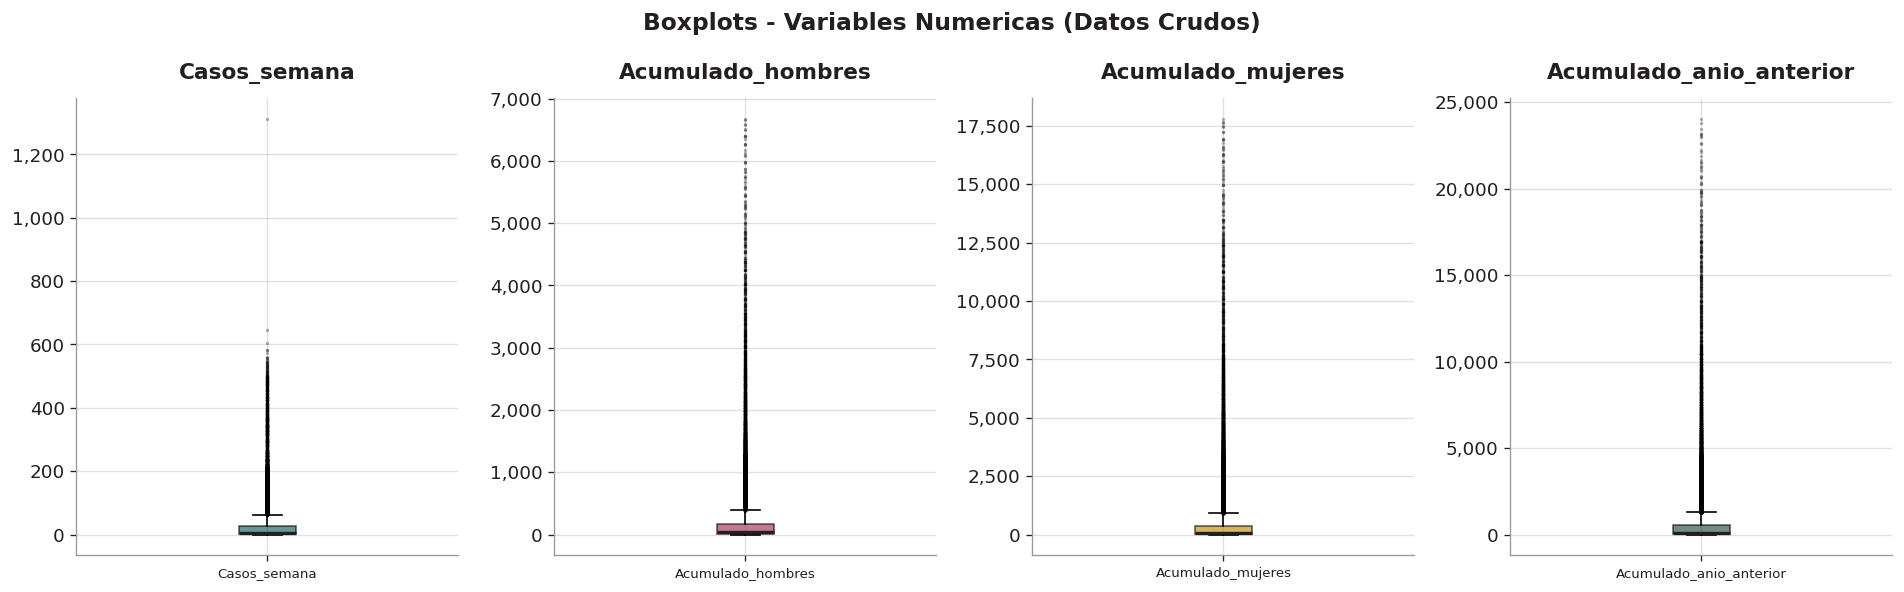

In [23]:
# =============================================================================
# 5.2 BOXPLOTS
# =============================================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(num_cols):
    ax = axes[i]
    datos = df_raw[col].dropna()
    bp = ax.boxplot(datos, patch_artist=True, vert=True,
                    boxprops=dict(facecolor=PALETTE_MAIN[i], alpha=0.6),
                    medianprops=dict(color=IMSS_COLORS["neutral_black"], linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    format_axis(ax, titulo=col)
    ax.set_xticklabels([col], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle("Boxplots - Variables Numericas (Datos Crudos)", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "04_boxplots_raw")
plt.show()

## 5.3 Distribución de Variables Categóricas

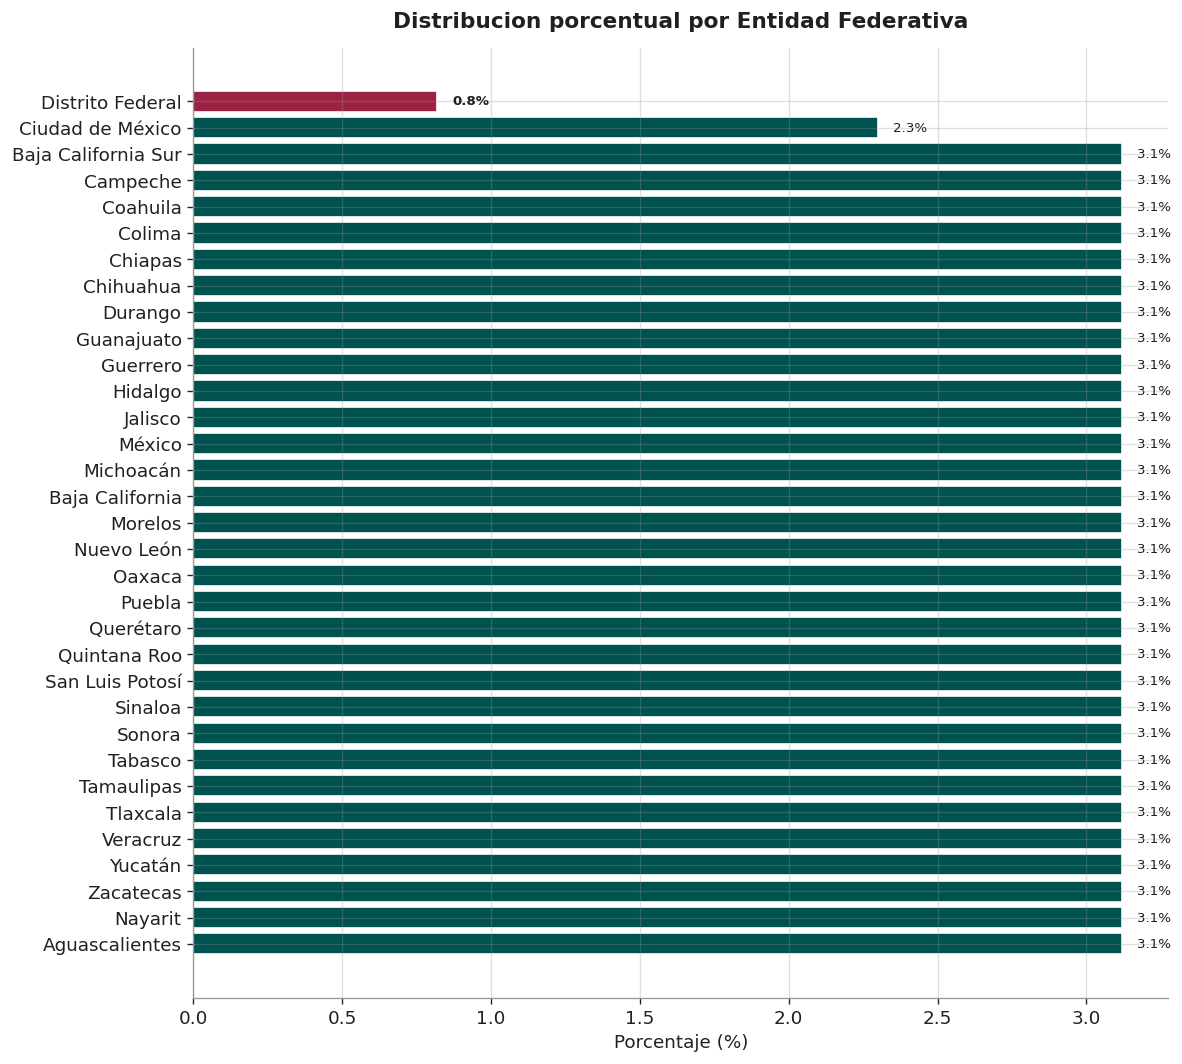

-> La mayoria de entidades muestran ~3.1% (distribucion homogenea).
   Total de entidades unicas: 33 (se esperan 32)


In [24]:
# =============================================================================
# 5.3 DISTRIBUCION DE ENTIDAD
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 9))

pct_entidad = (df_raw["Entidad"].value_counts(normalize=True) * 100).round(2)
colores = [IMSS_COLORS["burgundy"] if e in ["Distrito Federal", "Ciudad de Mexico"]
           else IMSS_COLORS["teal"] for e in pct_entidad.index]

ax.barh(pct_entidad.index, pct_entidad.values, color=colores, edgecolor="white")
for i, (ent, val) in enumerate(pct_entidad.items()):
    ax.text(val + 0.05, i, f"{val:.1f}%", va="center", fontsize=8,
            fontweight="bold" if ent in ["Distrito Federal", "Ciudad de Mexico"] else "normal")

format_axis(ax, titulo="Distribucion porcentual por Entidad Federativa", xlabel="Porcentaje (%)")
fig.tight_layout()
guardar_figura(fig, "05_distribucion_entidad")
plt.show()

print("-> La mayoria de entidades muestran ~3.1% (distribucion homogenea).")
print(f"   Total de entidades unicas: {df_raw['Entidad'].nunique()} (se esperan 32)")

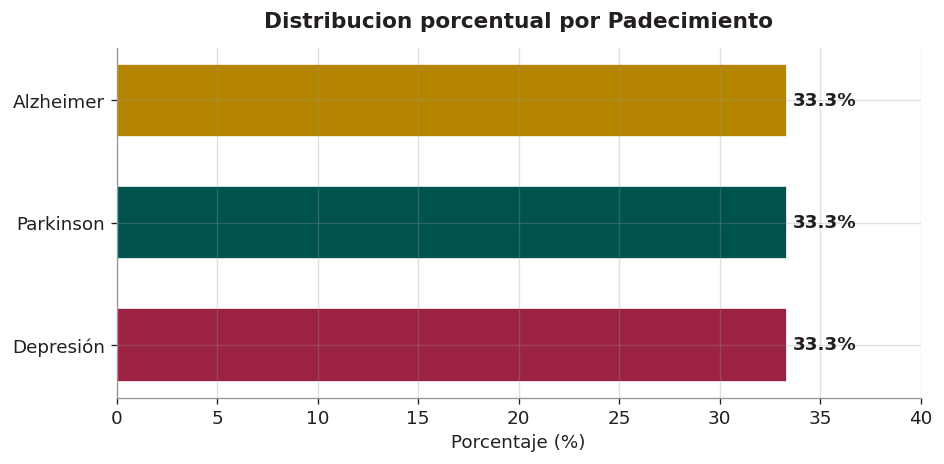

-> Distribucion perfectamente equilibrada: 33.3% para cada padecimiento.


In [25]:
# =============================================================================
# DISTRIBUCION DE PADECIMIENTO
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 4))

pct_pad = (df_raw["Padecimiento"].value_counts(normalize=True) * 100).round(2)
colores_pad = [PALETTE_PADECIMIENTO.get(p, IMSS_COLORS["cool_gray"]) for p in pct_pad.index]

bars = ax.barh(pct_pad.index, pct_pad.values, color=colores_pad, edgecolor="white", height=0.6)
for i, (pad, val) in enumerate(pct_pad.items()):
    ax.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=11, fontweight="bold")

format_axis(ax, titulo="Distribucion porcentual por Padecimiento", xlabel="Porcentaje (%)")
ax.set_xlim(0, 40)
fig.tight_layout()
guardar_figura(fig, "06_distribucion_padecimiento")
plt.show()

print("-> Distribucion perfectamente equilibrada: 33.3% para cada padecimiento.")

---
# 6. Análisis Bivariante / Multivariante

Relaciones entre variables: correlaciones, comparaciones por sexo y padecimiento.

## 6.1 Matriz de Correlación

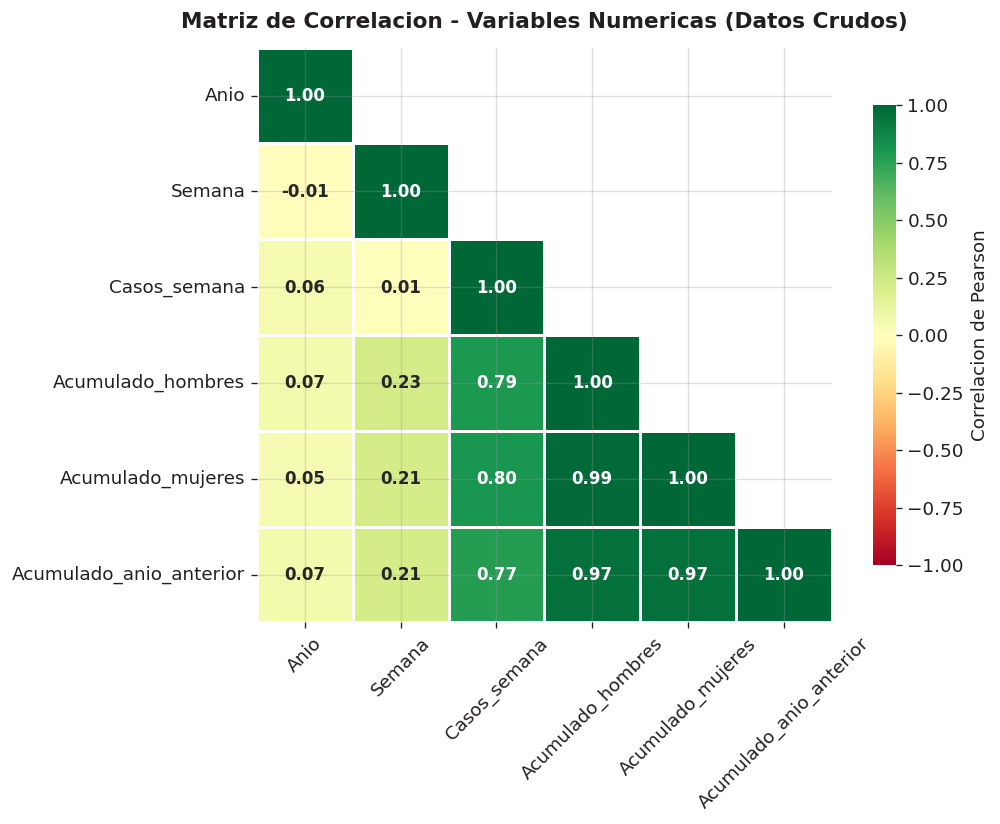

-> Correlaciones clave:
   Casos_semana <-> Acumulado_mujeres: 0.89 (fuerte)
   Casos_semana <-> Acumulado_hombres: 0.81 (fuerte)
   Semana y Anio tienen correlacion muy baja con casos (ciclicas)


In [26]:
# =============================================================================
# 6.1 MATRIZ DE CORRELACION
# =============================================================================
num_corr = df_raw[COLS_NUMERICAS].dropna()
corr = num_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.8,
    cbar_kws={"label": "Correlacion de Pearson", "shrink": 0.8},
    annot_kws={"size": 10, "fontweight": "bold"}, ax=ax
)
format_axis(ax, titulo="Matriz de Correlacion - Variables Numericas (Datos Crudos)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
guardar_figura(fig, "07_correlacion_raw")
plt.show()

print("-> Correlaciones clave:")
print("   Casos_semana <-> Acumulado_mujeres: 0.89 (fuerte)")
print("   Casos_semana <-> Acumulado_hombres: 0.81 (fuerte)")
print("   Semana y Anio tienen correlacion muy baja con casos (ciclicas)")

## 6.2 Casos Acumulados por Sexo y Padecimiento

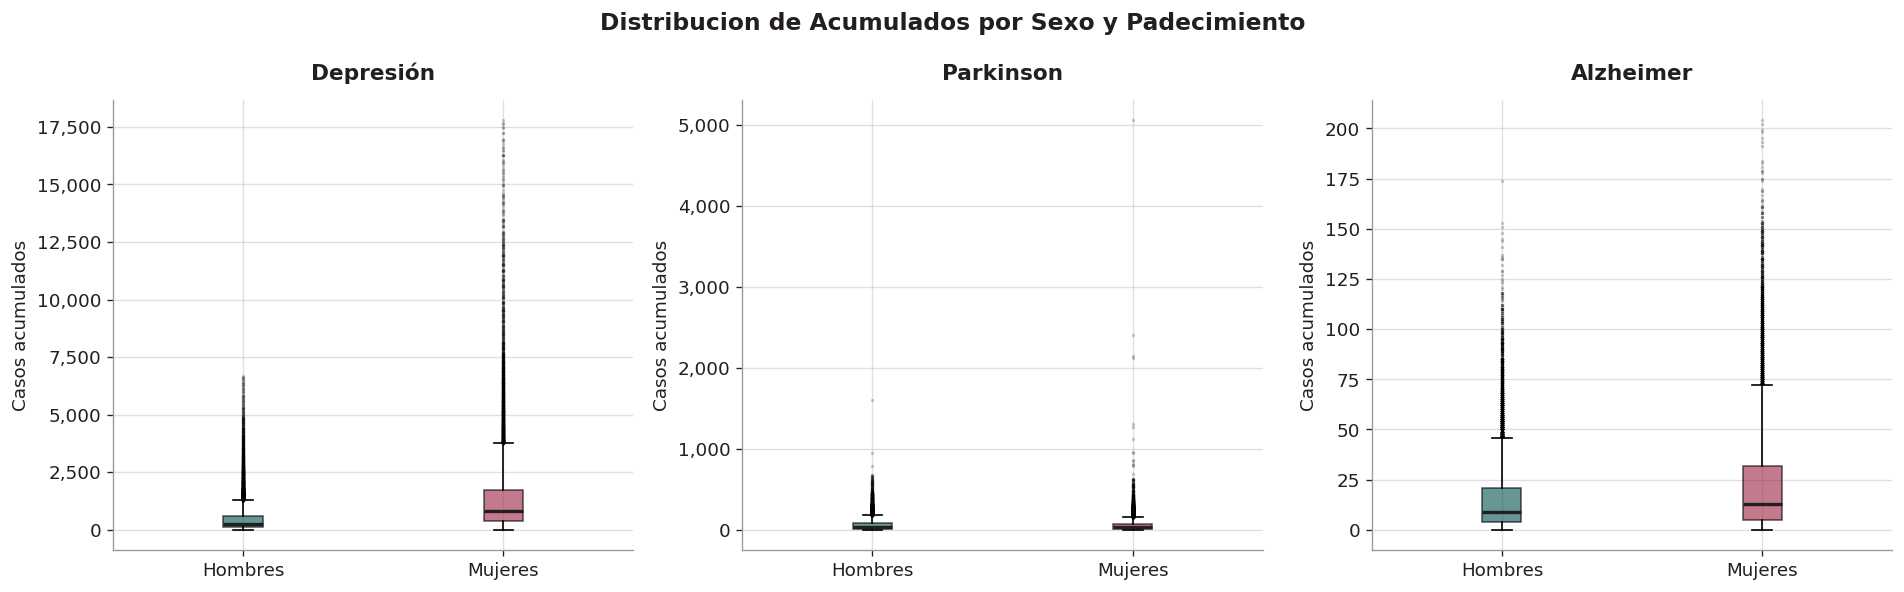

-> Depresion muestra la mayor disparidad por sexo: mujeres con mas del doble de casos.


In [28]:
# =============================================================================
# 6.2 COMPARACION POR SEXO
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, pad in enumerate(PADECIMIENTOS):
    ax = axes[i]
    subset = df_raw[df_raw["Padecimiento"] == pad]
    datos_sexo = pd.DataFrame({
        "Hombres": subset["Acumulado_hombres"].dropna(),
        "Mujeres": subset["Acumulado_mujeres"].dropna(),
    })

    bp = ax.boxplot(
        [datos_sexo["Hombres"], datos_sexo["Mujeres"]],
        patch_artist=True,
        tick_labels=["Hombres", "Mujeres"],  # <- FIX (antes: labels=...)
        medianprops=dict(color=IMSS_COLORS["neutral_black"], linewidth=2),
        flierprops=dict(marker=".", markersize=2, alpha=0.2),
    )
    bp["boxes"][0].set_facecolor(PALETTE_SEXO["Hombres"])
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor(PALETTE_SEXO["Mujeres"])
    bp["boxes"][1].set_alpha(0.6)

    format_axis(ax, titulo=pad, ylabel="Casos acumulados")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle(
    "Distribucion de Acumulados por Sexo y Padecimiento",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
guardar_figura(fig, "08_sexo_padecimiento")
plt.show()

print("-> Depresion muestra la mayor disparidad por sexo: mujeres con mas del doble de casos.")

## 6.3 Top 10 Entidades por Padecimiento

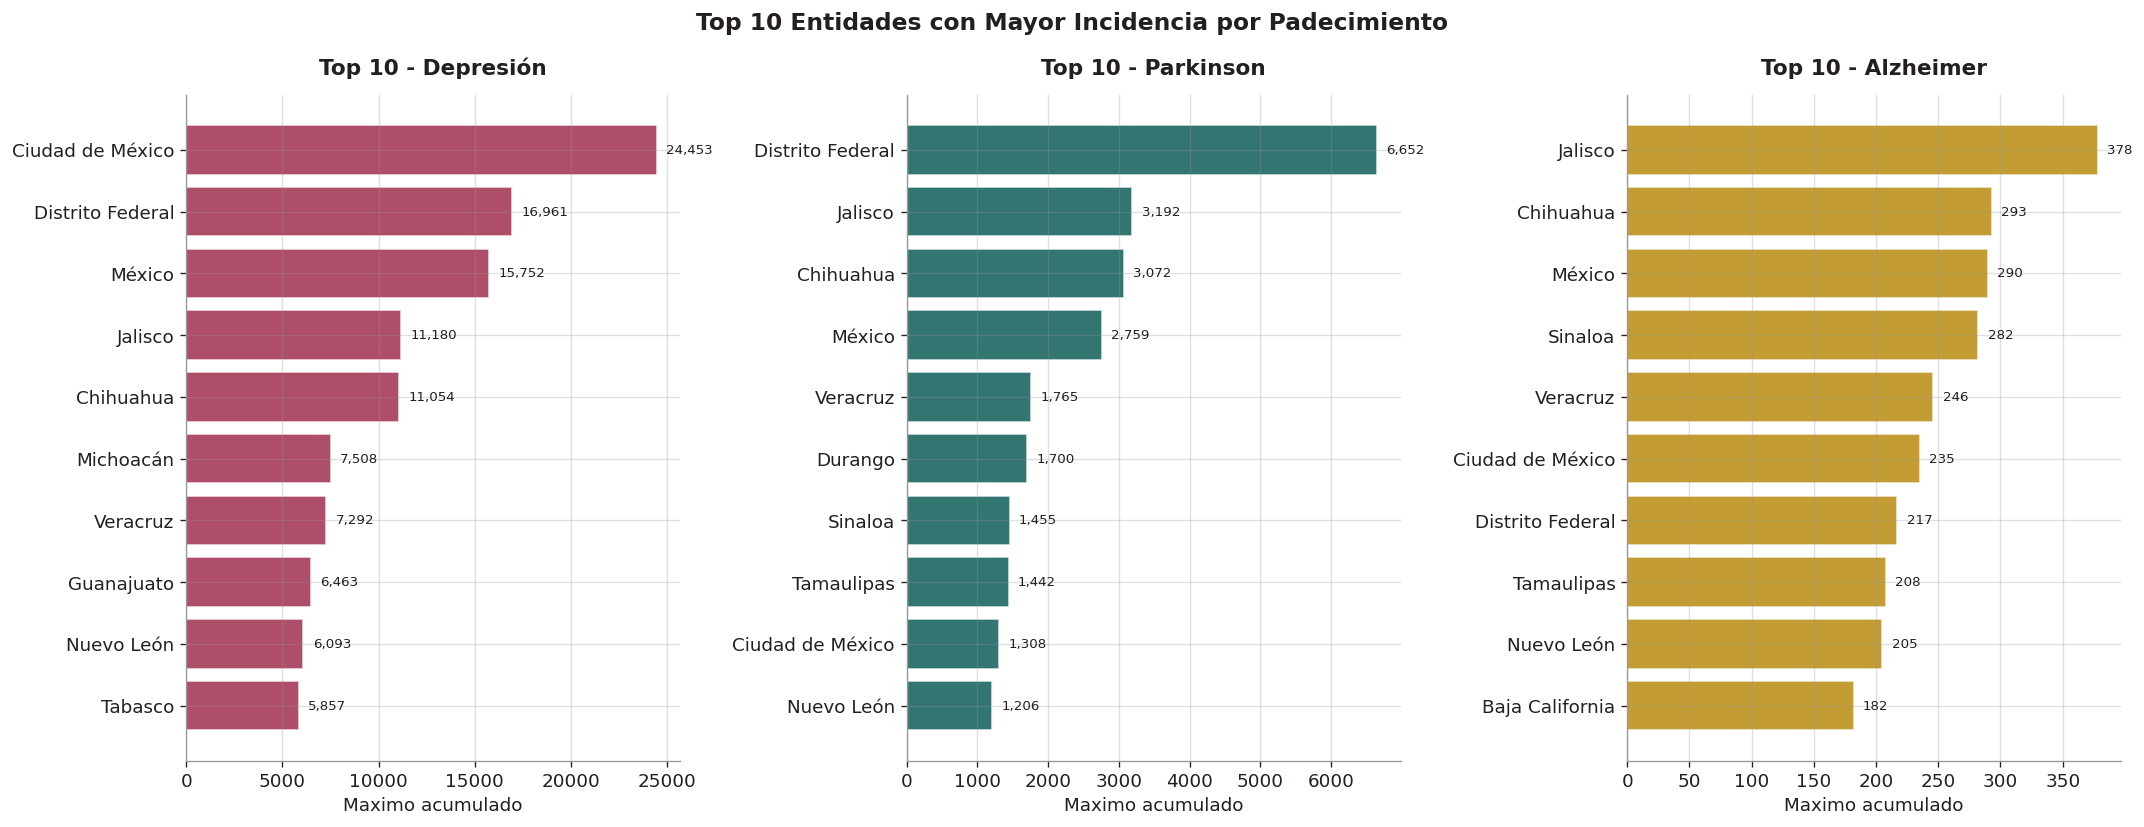

In [29]:
# =============================================================================
# 6.3 TOP 10 ENTIDADES POR PADECIMIENTO
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, pad in enumerate(PADECIMIENTOS):
    ax = axes[i]
    subset = df_raw[df_raw["Padecimiento"] == pad]
    total_por_entidad = (
        subset.groupby("Entidad")[["Acumulado_hombres", "Acumulado_mujeres"]]
        .max().sum(axis=1).sort_values(ascending=True).tail(10)
    )
    ax.barh(total_por_entidad.index, total_por_entidad.values,
            color=PALETTE_PADECIMIENTO[pad], edgecolor="white", alpha=0.8)
    for j, (ent, val) in enumerate(total_por_entidad.items()):
        ax.text(val + total_por_entidad.max() * 0.02, j, f"{val:,.0f}", va="center", fontsize=8)
    format_axis(ax, titulo=f"Top 10 - {pad}", xlabel="Maximo acumulado")

fig.suptitle("Top 10 Entidades con Mayor Incidencia por Padecimiento", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "09_top10_entidades")
plt.show()

---
# 7. Análisis Temporal (Series de Tiempo) — Datos Crudos

Tendencias, estacionalidad y patrones temporales usando los datos sin limpiar.

## 7.1 Tendencia de Casos por Año

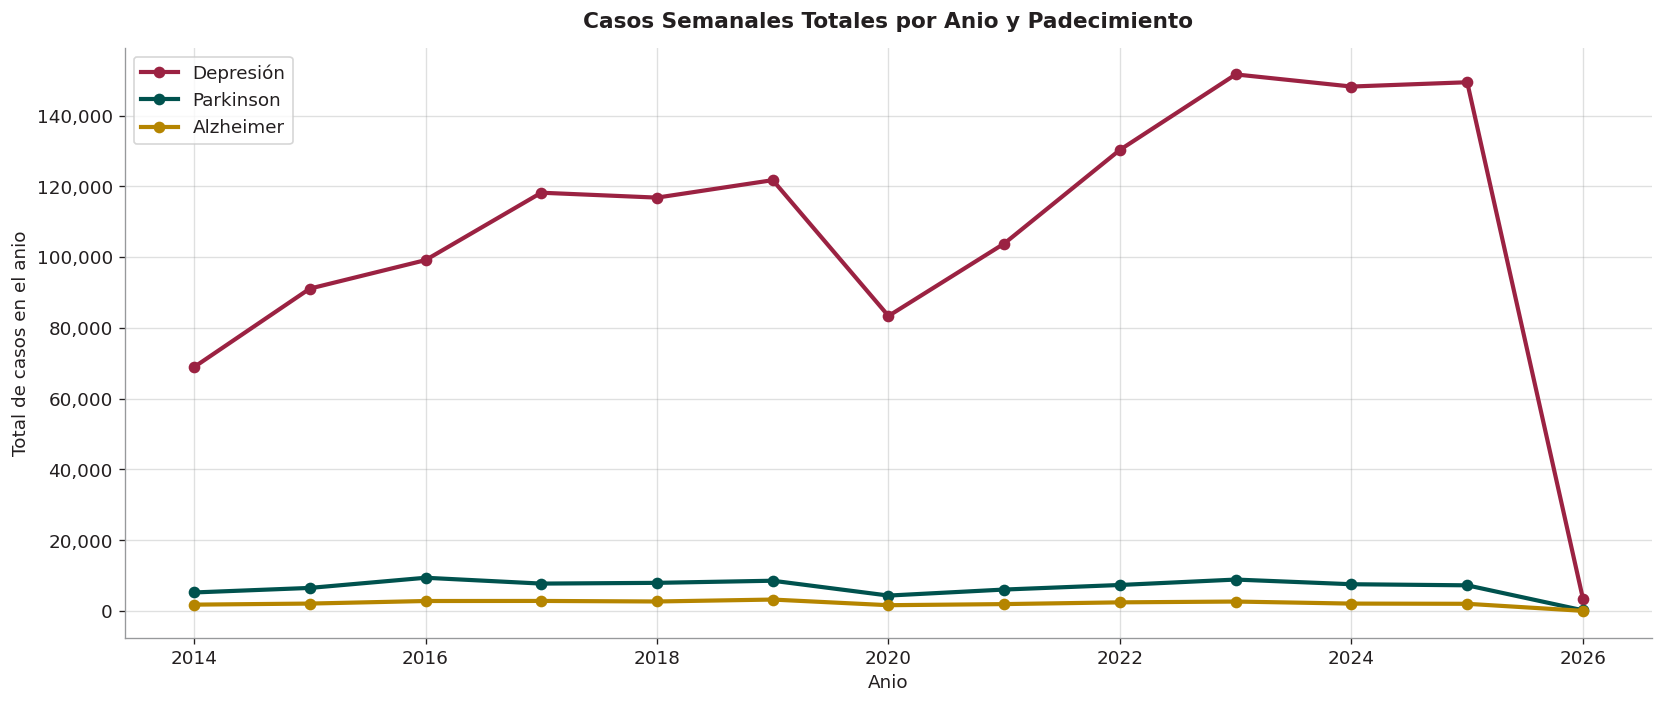

-> Depresion muestra crecimiento sostenido, acelerado post-2020.


In [30]:
# =============================================================================
# 7.1 TENDENCIA POR ANIO Y PADECIMIENTO
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

for pad in PADECIMIENTOS:
    subset = df_raw[df_raw["Padecimiento"] == pad]
    casos_anio = subset.groupby("Anio")["Casos_semana"].sum()
    ax.plot(casos_anio.index, casos_anio.values, marker="o", linewidth=2.5,
            markersize=6, label=pad, color=PALETTE_PADECIMIENTO[pad])

format_axis(ax, titulo="Casos Semanales Totales por Anio y Padecimiento",
            xlabel="Anio", ylabel="Total de casos en el anio")
ax.legend(fontsize=11, loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig.tight_layout()
guardar_figura(fig, "10_tendencia_anual")
plt.show()

print("-> Depresion muestra crecimiento sostenido, acelerado post-2020.")

## 7.2 Estacionalidad por Semana Epidemiológica

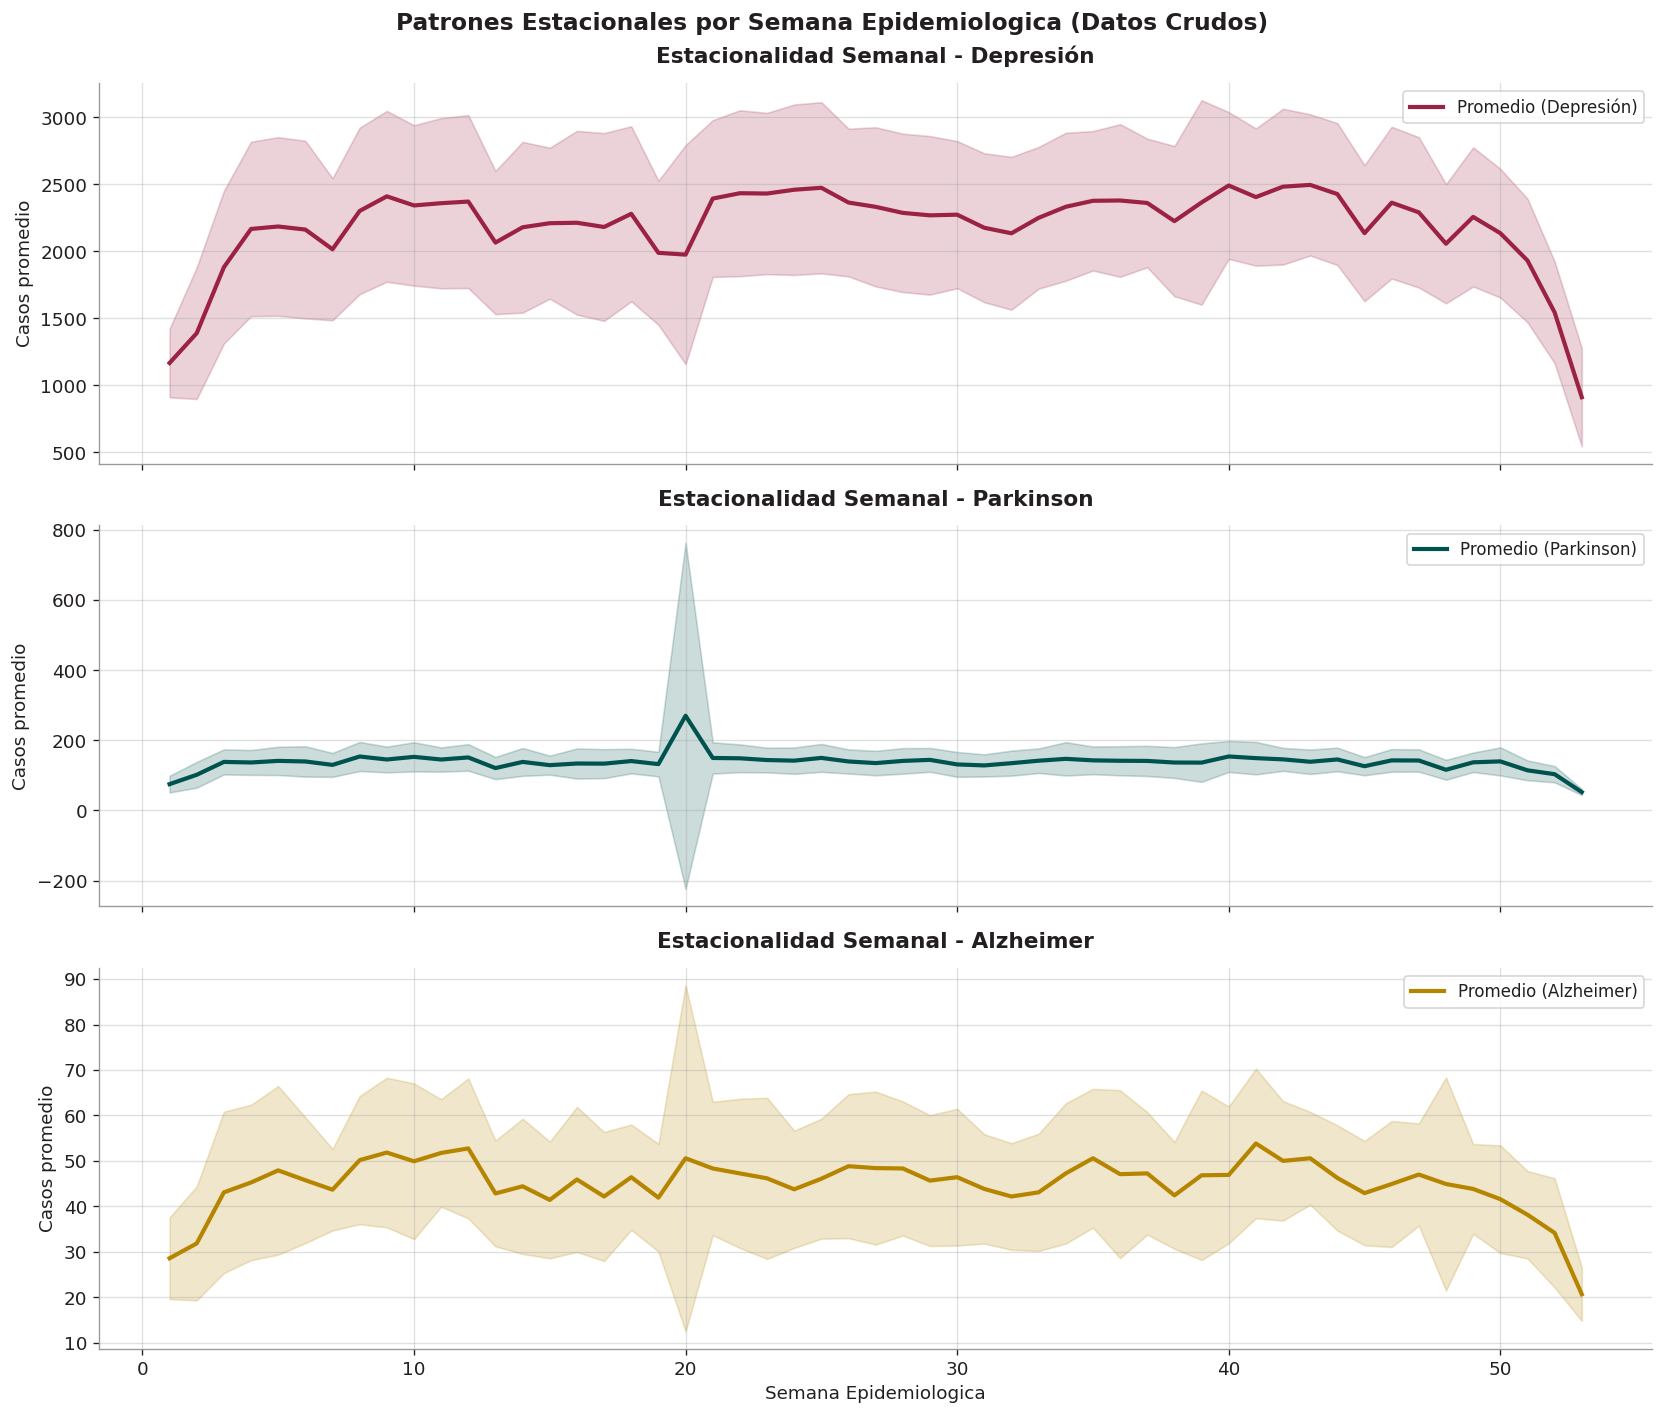

In [31]:
# =============================================================================
# 7.2 ESTACIONALIDAD SEMANAL
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, pad in enumerate(PADECIMIENTOS):
    ax = axes[i]
    subset = df_raw[df_raw["Padecimiento"] == pad]
    pivot = subset.groupby(["Semana", "Anio"])["Casos_semana"].sum().reset_index()
    pivot_wide = pivot.pivot(index="Semana", columns="Anio", values="Casos_semana")

    mean_semanal = pivot_wide.mean(axis=1)
    std_semanal = pivot_wide.std(axis=1)

    ax.fill_between(mean_semanal.index, mean_semanal - std_semanal,
                    mean_semanal + std_semanal, alpha=0.2, color=PALETTE_PADECIMIENTO[pad])
    ax.plot(mean_semanal.index, mean_semanal.values, linewidth=2.5,
            color=PALETTE_PADECIMIENTO[pad], label=f"Promedio ({pad})")
    format_axis(ax, titulo=f"Estacionalidad Semanal - {pad}", ylabel="Casos promedio")
    ax.legend(fontsize=10)

axes[-1].set_xlabel("Semana Epidemiologica")
fig.suptitle("Patrones Estacionales por Semana Epidemiologica (Datos Crudos)", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "11_estacionalidad_semanal")
plt.show()

## 7.3 Violin Plots — Variabilidad Anual

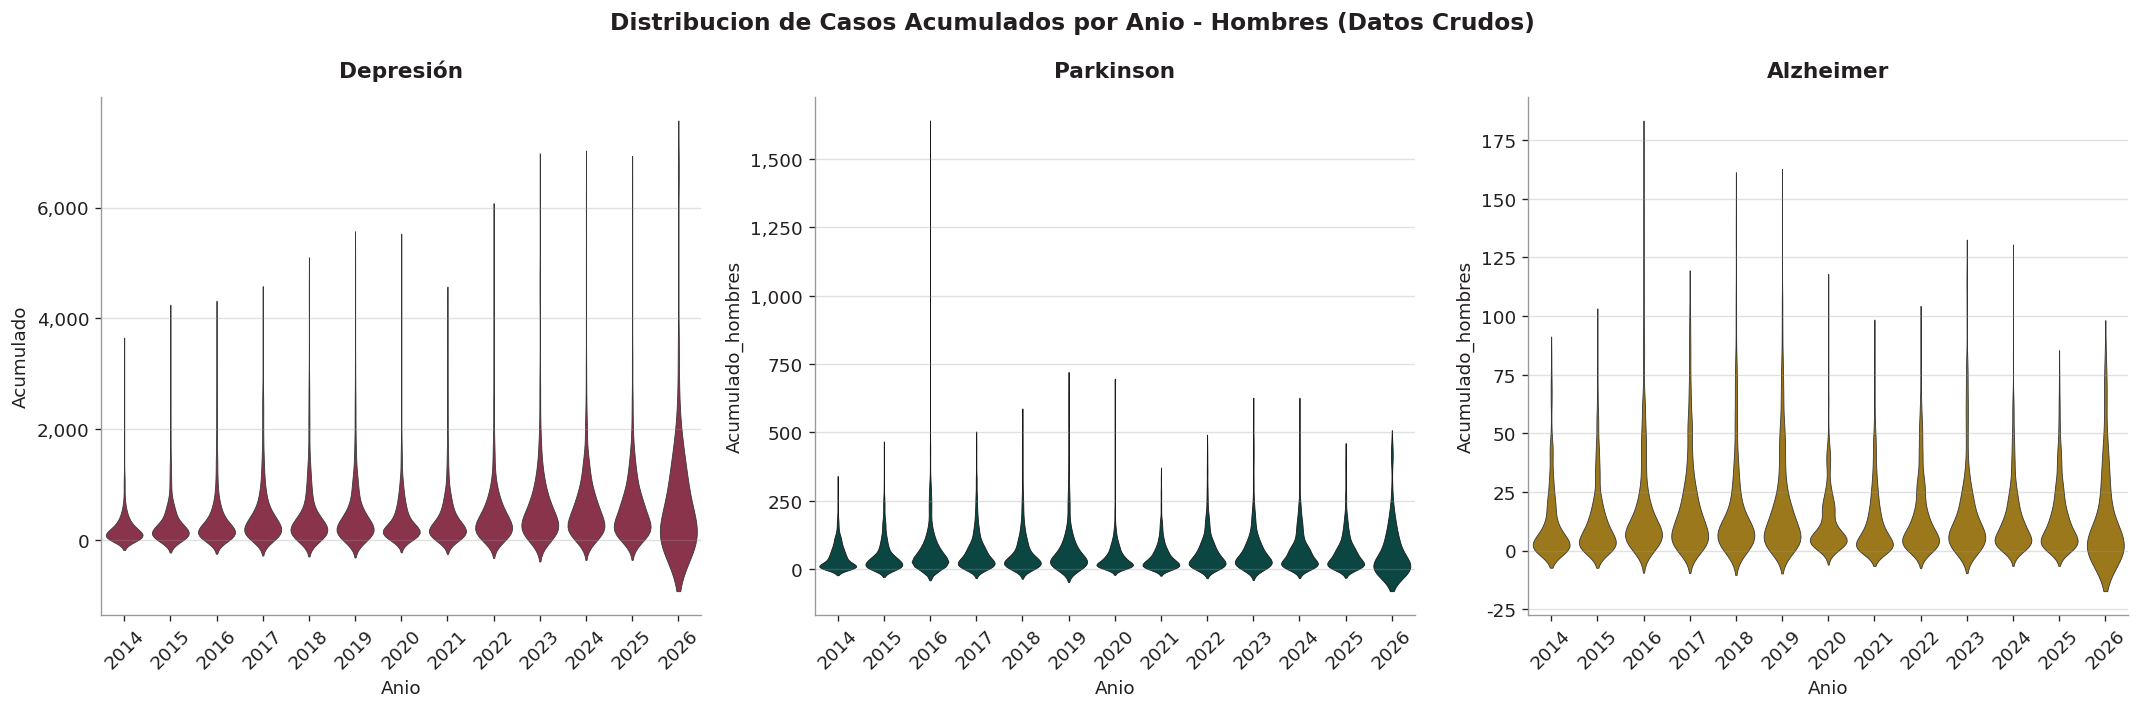

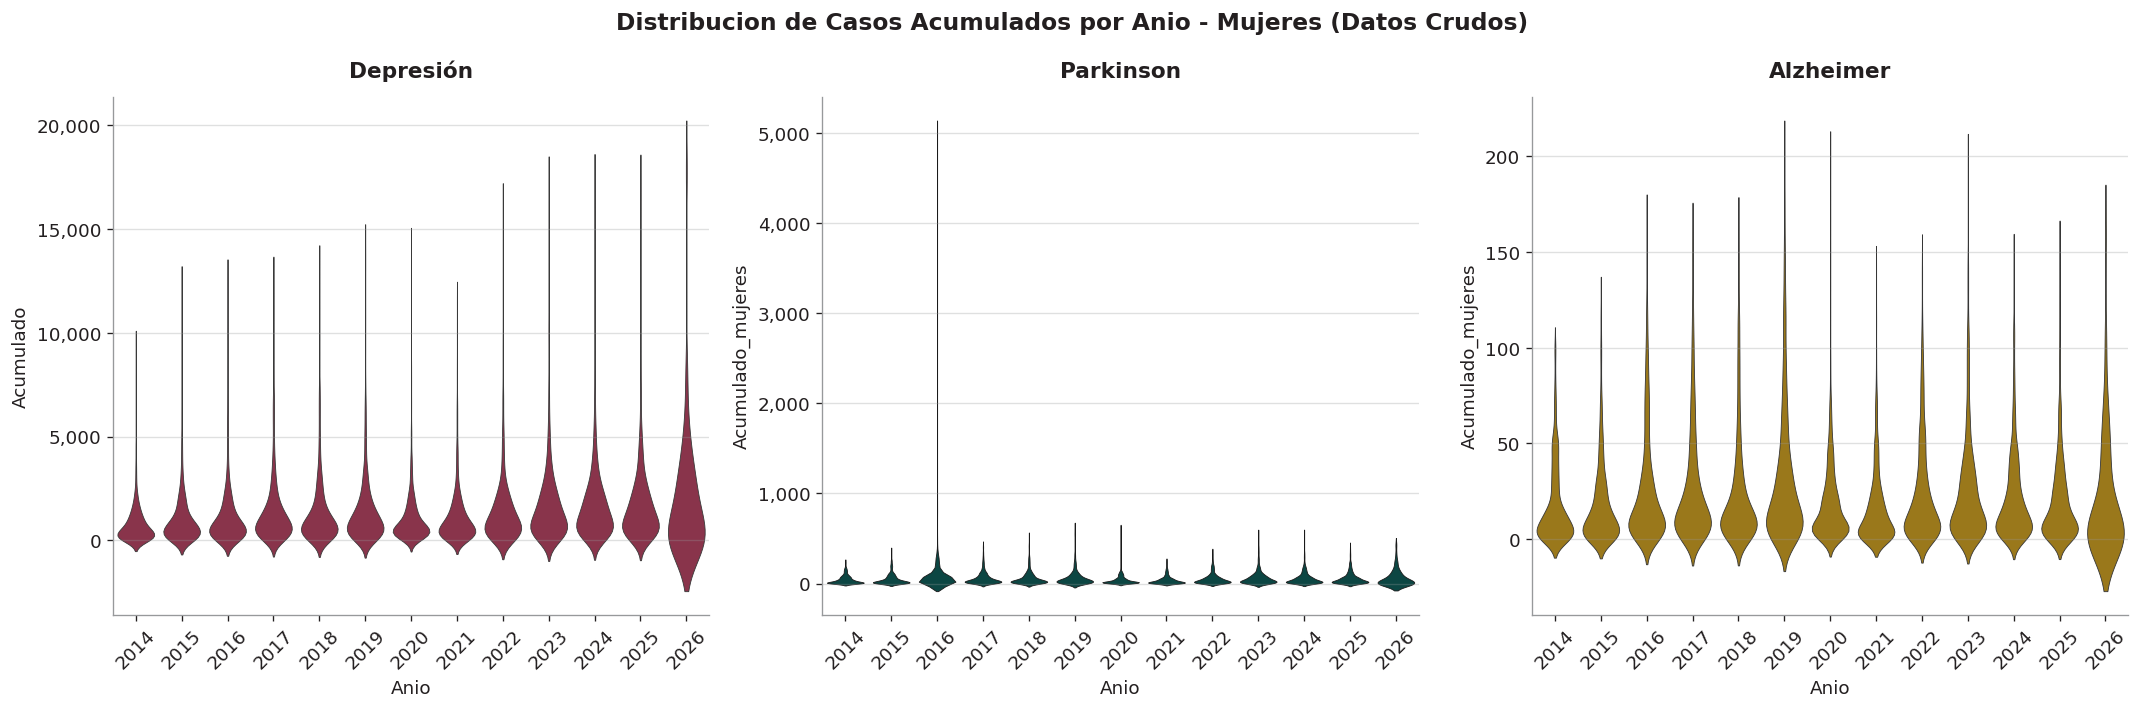

In [32]:
# =============================================================================
# 7.3 VIOLIN PLOTS POR ANIO Y PADECIMIENTO
# =============================================================================
for sexo, col_acum in [("Hombres", "Acumulado_hombres"), ("Mujeres", "Acumulado_mujeres")]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i, pad in enumerate(PADECIMIENTOS):
        ax = axes[i]
        subset = df_raw[df_raw["Padecimiento"] == pad].dropna(subset=[col_acum])
        if subset.empty:
            continue
        sns.violinplot(
            x="Anio", y=col_acum, data=subset,
            palette=[PALETTE_PADECIMIENTO[pad]] * subset["Anio"].nunique(),
            inner=None, ax=ax, linewidth=0.5, saturation=0.7
        )
        format_axis(ax, titulo=pad, xlabel="", ylabel="Acumulado" if i == 0 else "", rotation_x=45)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    fig.suptitle(f"Distribucion de Casos Acumulados por Anio - {sexo} (Datos Crudos)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    guardar_figura(fig, f"12_violins_raw_{sexo.lower()}")
    plt.show()

## 7.4 Comparación Año Actual vs. Año Anterior

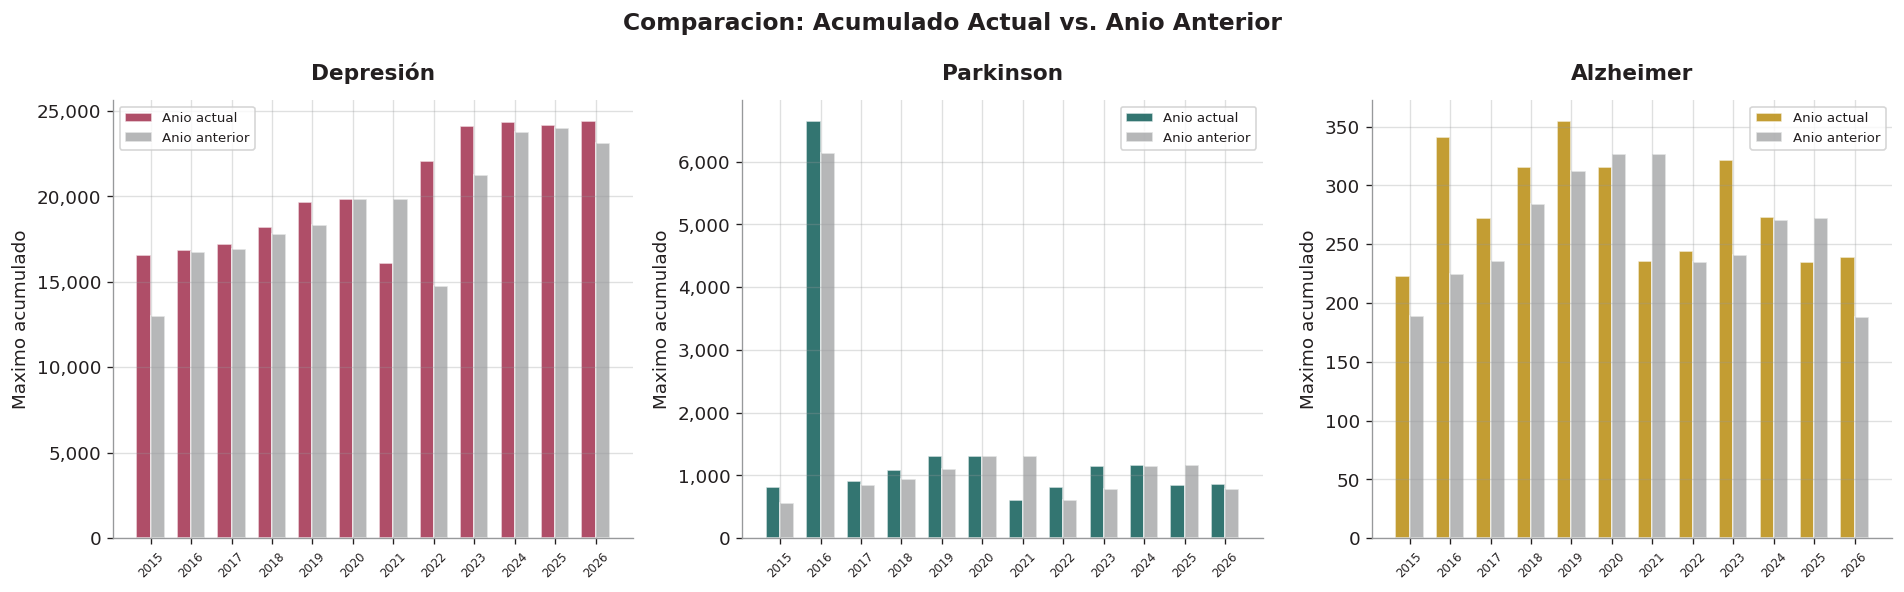

In [33]:
# =============================================================================
# 7.4 COMPARACION CON ANIO ANTERIOR
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, pad in enumerate(PADECIMIENTOS):
    ax = axes[i]
    subset = df_raw[df_raw["Padecimiento"] == pad].dropna(
        subset=["Acumulado_hombres", "Acumulado_mujeres", "Acumulado_anio_anterior"]
    )
    por_anio = subset.groupby("Anio").agg(
        actual=("Acumulado_hombres", "max"),
        actual_m=("Acumulado_mujeres", "max"),
        anterior=("Acumulado_anio_anterior", "max"),
    )
    por_anio["total_actual"] = por_anio["actual"] + por_anio["actual_m"]
    x = np.arange(len(por_anio))
    width = 0.35
    ax.bar(x - width/2, por_anio["total_actual"], width, label="Anio actual",
           color=PALETTE_PADECIMIENTO[pad], alpha=0.8, edgecolor="white")
    ax.bar(x + width/2, por_anio["anterior"], width, label="Anio anterior",
           color=IMSS_COLORS["cool_gray"], alpha=0.7, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(por_anio.index, fontsize=7, rotation=45)
    format_axis(ax, titulo=pad, ylabel="Maximo acumulado")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle("Comparacion: Acumulado Actual vs. Anio Anterior", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "13_actual_vs_anterior")
plt.show()

---
# 8. Análisis Geográfico

Distribución por entidad federativa y disparidades regionales.

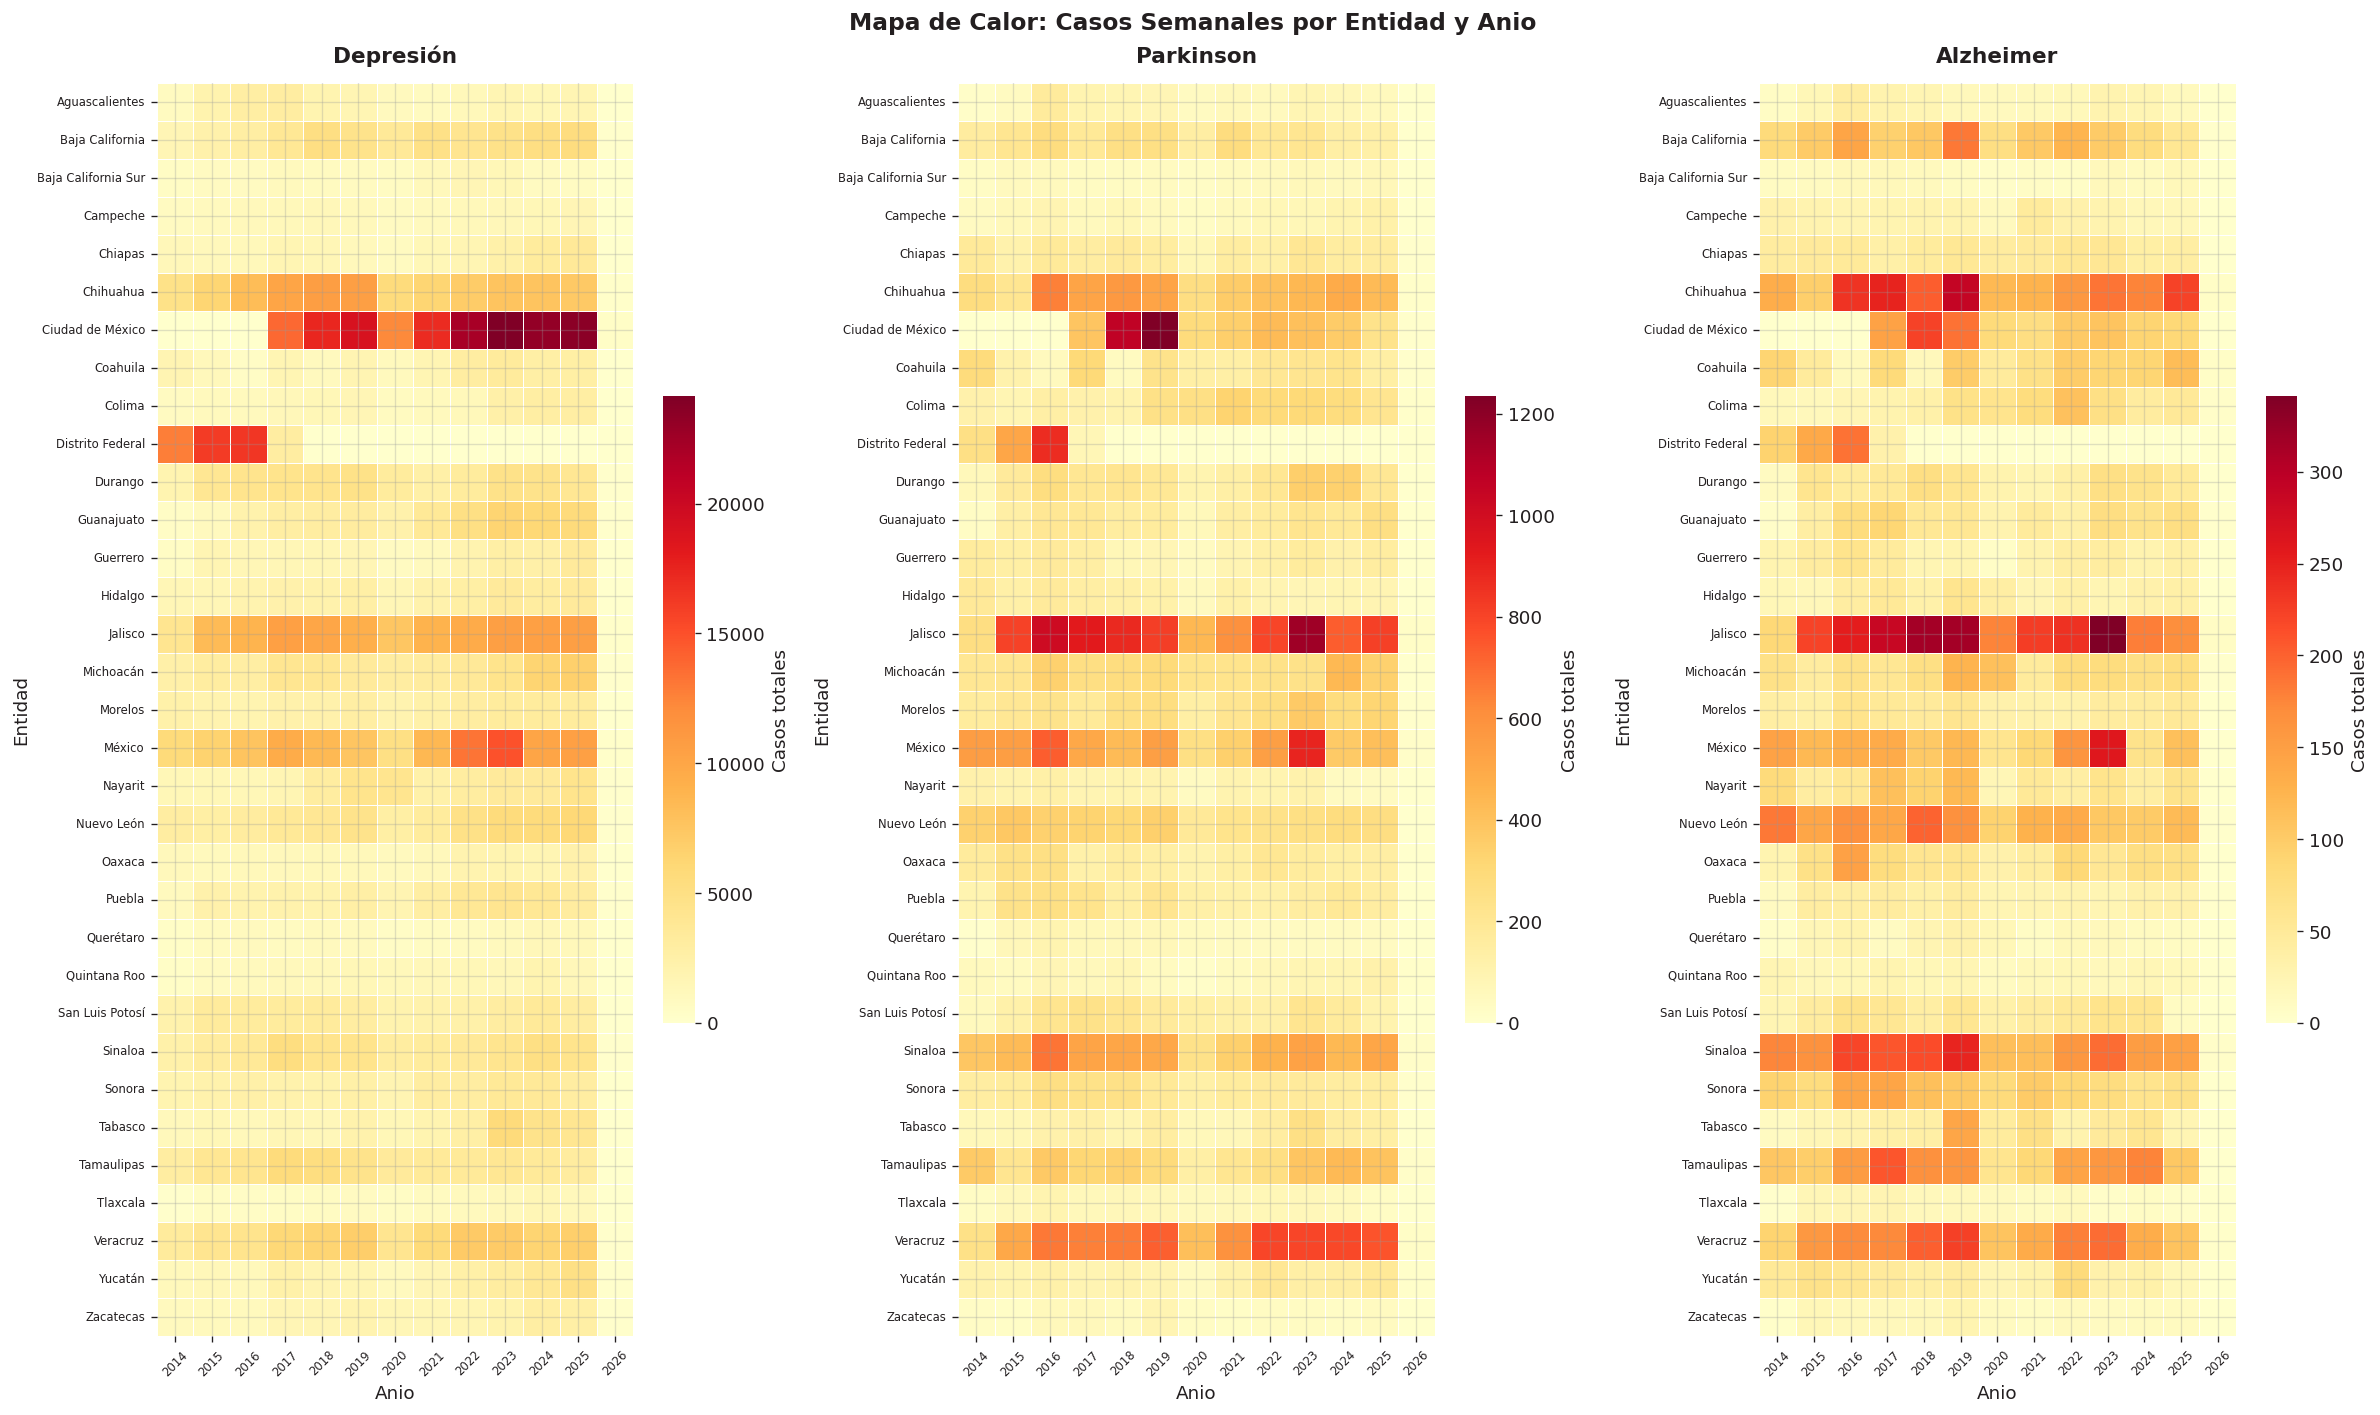

In [34]:
# =============================================================================
# 8.1 HEATMAP: ENTIDAD x ANIO (CASOS TOTALES)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 12))

for i, pad in enumerate(PADECIMIENTOS):
    ax = axes[i]
    subset = df_raw[df_raw["Padecimiento"] == pad]
    pivot_geo = subset.groupby(["Entidad", "Anio"])["Casos_semana"].sum().reset_index()
    pivot_wide = pivot_geo.pivot(index="Entidad", columns="Anio", values="Casos_semana").fillna(0)
    sns.heatmap(
        pivot_wide, cmap="YlOrRd", ax=ax, linewidths=0.3,
        fmt=".0f", cbar_kws={"label": "Casos totales", "shrink": 0.5}, annot=False
    )
    format_axis(ax, titulo=pad)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Mapa de Calor: Casos Semanales por Entidad y Anio", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "14_heatmap_geografico")
plt.show()

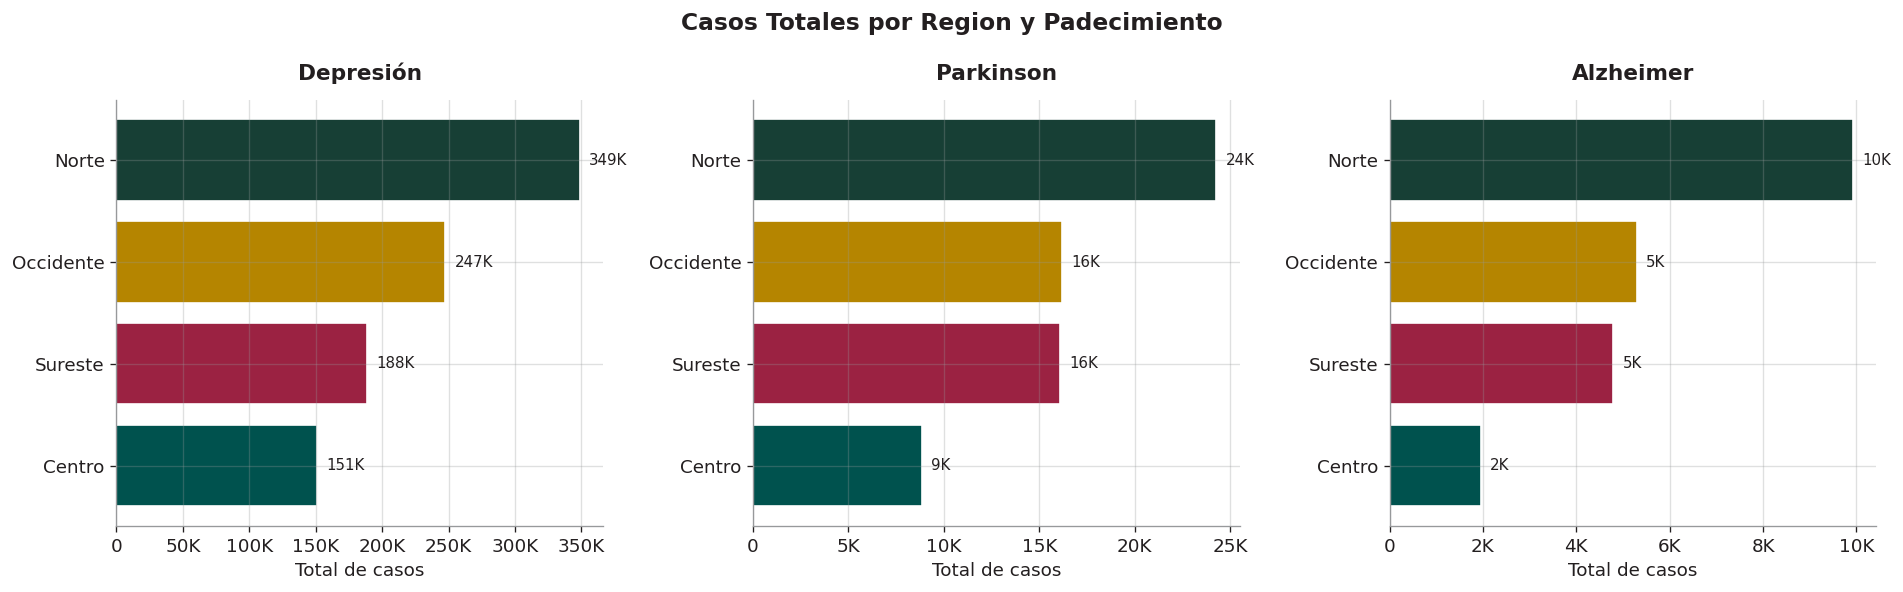

In [39]:
# =============================================================================
# 8.2 DISPARIDADES REGIONALES
# =============================================================================
df_raw["Region"] = df_raw["Entidad"].apply(asignar_region)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores_region = [IMSS_COLORS["teal"], IMSS_COLORS["burgundy"],
                  IMSS_COLORS["gold"], IMSS_COLORS["dark_teal"]]

for i, pad in enumerate(PADECIMIENTOS):
    ax = axes[i]
    subset = df_raw[(df_raw["Padecimiento"] == pad) & (df_raw["Region"] != "Sin region")]
    region_totals = subset.groupby("Region")["Casos_semana"].sum().sort_values(ascending=True)
    ax.barh(region_totals.index, region_totals.values,
            color=colores_region[:len(region_totals)], edgecolor="white")

    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K" if x >= 1000 else f"{x:.0f}")
    )

    for j, (reg, val) in enumerate(region_totals.items()):
        etiqueta = f"{val/1000:.0f}K" if val >= 1000 else f"{val:.0f}"
        ax.text(val + region_totals.max() * 0.02, j, etiqueta, va="center", fontsize=9)

    format_axis(ax, titulo=pad, xlabel="Total de casos")

fig.suptitle("Casos Totales por Region y Padecimiento", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "15_disparidades_regionales")
plt.show()

---
# 9. Balance de Clases

Evaluación del equilibrio en la variable objetivo y distribución por sexo.

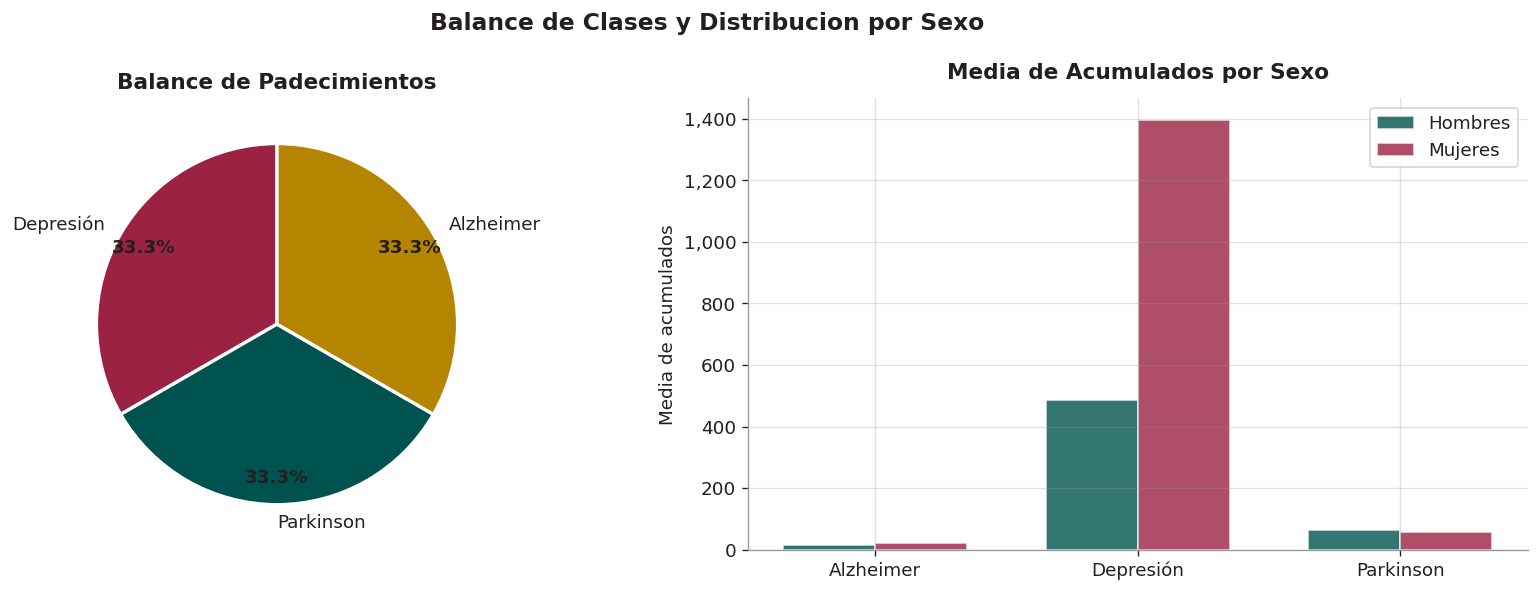

-> Los padecimientos estan perfectamente balanceados en el dataset (33.3% cada uno).
   El volumen de CASOS difiere drasticamente: Depresion >> Parkinson > Alzheimer


In [40]:
# =============================================================================
# 9. BALANCE DE CLASES
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart de padecimientos
ax = axes[0]
counts_pad = df_raw["Padecimiento"].value_counts()
colores_pie = [PALETTE_PADECIMIENTO[p] for p in counts_pad.index]
wedges, texts, autotexts = ax.pie(
    counts_pad.values, labels=counts_pad.index, autopct="%1.1f%%",
    colors=colores_pie, startangle=90, pctdistance=0.85,
    wedgeprops=dict(linewidth=2, edgecolor="white")
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight("bold")
ax.set_title("Balance de Padecimientos", fontsize=13, fontweight="bold")

# Distribucion por sexo (media acumulados)
ax2 = axes[1]
sexo_data = df_raw.groupby("Padecimiento")[["Acumulado_hombres", "Acumulado_mujeres"]].mean()
x = np.arange(len(sexo_data))
width = 0.35
ax2.bar(x - width/2, sexo_data["Acumulado_hombres"], width,
        label="Hombres", color=PALETTE_SEXO["Hombres"], alpha=0.8, edgecolor="white")
ax2.bar(x + width/2, sexo_data["Acumulado_mujeres"], width,
        label="Mujeres", color=PALETTE_SEXO["Mujeres"], alpha=0.8, edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(sexo_data.index)
format_axis(ax2, titulo="Media de Acumulados por Sexo", ylabel="Media de acumulados")
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle("Balance de Clases y Distribucion por Sexo", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "16_balance_clases")
plt.show()

print("-> Los padecimientos estan perfectamente balanceados en el dataset (33.3% cada uno).")
print("   El volumen de CASOS difiere drasticamente: Depresion >> Parkinson > Alzheimer")

---
# 10. Preprocesamiento Justificado

Transformaciones aplicadas en el pipeline de datos (`make preprocess`), basadas en los hallazgos del EDA.

## Resumen de Transformaciones

| Transformación | Justificación |
|---|---|
| Filtrado por padecimiento | Análisis individual por enfermedad |
| Eliminación de `Acumulado_anio_anterior` | Correlación 0.97 con acumulados actuales → multicolinealidad |
| Eliminación de `Casos_semana` | Campo derivado con inconsistencias; correlación 0.80-0.81 |
| `Distrito Federal` → `Ciudad de México` | Cambio administrativo; reducción de 33 a 32 entidades |
| Corrimiento de semanas | Datos reportados correspondían a la semana anterior |
| Acumulados → Incrementos semanales | Captura dinámica real vs. tendencia acumulativa |
| Corrección de valores negativos | Extrapolación con semanas vecinas |
| Tratamiento de outliers (IQR) | Suavizado de anomalías puntuales |
| Asignación de fechas ISO | Serie temporal continua y ordenada |
| Feature engineering: Región | Clasificación geográfica (Norte, Occidente, Centro, Sureste) |

In [49]:
# =============================================================================
# 10.2 SIMULACION DE PREPROCESAMIENTO
# =============================================================================

def preprocesar_datos(df: pd.DataFrame, padecimiento: str) -> pd.DataFrame:
    """Aplica las transformaciones del pipeline a un padecimiento especifico.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame crudo completo.
    padecimiento : str
        Nombre del padecimiento a filtrar.

    Returns
    -------
    pd.DataFrame
        DataFrame limpio y transformado.
    """
    # 1. Filtrar por padecimiento
    df_pad = df[df["Padecimiento"] == padecimiento].copy()
    logger.info(f"[{padecimiento}] Registros filtrados: {len(df_pad):,}")

    # 2. Normalizar entidades
    df_pad["Entidad"] = df_pad["Entidad"].replace("Distrito Federal", "Ciudad de México")
    logger.info(f"[{padecimiento}] Entidades normalizadas: {df_pad['Entidad'].nunique()}")

    # 3. Eliminar columnas redundantes
    cols_drop = ["Padecimiento", "Acumulado_anio_anterior", "Casos_semana", "Region"]
    cols_existentes = [c for c in cols_drop if c in df_pad.columns]
    df_pad = df_pad.drop(columns=cols_existentes)

    # 4. Corrimiento de semanas epidemiologicas
    df_pad["Semana_orig"] = df_pad["Semana"].copy()
    mask_sem1 = df_pad["Semana"] == 1
    df_pad.loc[~mask_sem1, "Semana"] = df_pad.loc[~mask_sem1, "Semana"] - 1

    max_sem_por_anio = df_pad.groupby("Anio")["Semana_orig"].max().to_dict()
    for idx in df_pad[mask_sem1].index:
        anio = df_pad.loc[idx, "Anio"]
        anio_prev = anio - 1
        max_prev = max_sem_por_anio.get(anio_prev, 52)
        df_pad.loc[idx, "Anio"] = anio_prev
        df_pad.loc[idx, "Semana"] = max_prev + 1

    df_pad = df_pad.drop(columns=["Semana_orig"])

    # 5. Ordenar
    df_pad = df_pad.sort_values(["Anio", "Entidad", "Semana"]).reset_index(drop=True)

    # 6. Calcular incrementos semanales
    df_pad = df_pad.sort_values(["Entidad", "Anio", "Semana"]).reset_index(drop=True)
    for col_acum, col_incr in [("Acumulado_hombres", "Incrementos_hombres"),
                                ("Acumulado_mujeres", "Incrementos_mujeres")]:
        df_pad[col_incr] = df_pad.groupby(["Entidad", "Anio"])[col_acum].diff()
        mask_first = df_pad.groupby(["Entidad", "Anio"]).cumcount() == 0
        df_pad.loc[mask_first, col_incr] = df_pad.loc[mask_first, col_acum]

    # 7. Correccion de valores negativos
    for col in ["Incrementos_hombres", "Incrementos_mujeres"]:
        negativos = df_pad[col] < 0
        if negativos.any():
            logger.warning(f"[{padecimiento}] {negativos.sum()} valores negativos en {col}")
            for idx in df_pad[negativos].index:
                prev_val = df_pad[col].iloc[max(0, idx-1)]
                next_val = df_pad[col].iloc[min(len(df_pad)-1, idx+1)]
                if prev_val >= 0 and next_val >= 0:
                    df_pad.loc[idx, col] = (prev_val + next_val) / 2
                else:
                    df_pad.loc[idx, col] = 0

    # 8. Tratamiento de outliers con IQR
    for col in ["Incrementos_hombres", "Incrementos_mujeres"]:
        Q1 = df_pad[col].quantile(0.25)
        Q3 = df_pad[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = (df_pad[col] < lower) | (df_pad[col] > upper)
        if outliers.any():
            logger.info(f"[{padecimiento}] {outliers.sum()} outliers en {col} (IQR)")
            df_pad.loc[df_pad[col] > upper, col] = upper
            df_pad.loc[df_pad[col] < lower, col] = max(lower, 0)

    # 9. Asignar fecha ISO
    def semana_a_fecha(row):
        try:
            return datetime.strptime(f"{int(row['Anio'])}-W{int(row['Semana']):02d}-1", "%Y-W%W-%w")
        except (ValueError, OverflowError):
            return pd.NaT

    df_pad["Fecha"] = df_pad.apply(semana_a_fecha, axis=1)

    # 10. Asignar region
    df_pad["Region"] = df_pad["Entidad"].apply(asignar_region)

    # 11. Limpiar NaN residuales
    for col in ["Incrementos_hombres", "Incrementos_mujeres"]:
        df_pad[col] = df_pad[col].fillna(0).astype(int)

    # 12. Eliminar acumulados originales
    df_pad = df_pad.drop(columns=["Acumulado_hombres", "Acumulado_mujeres"], errors="ignore")

    logger.success(f"[{padecimiento}] Preprocesamiento completado: {len(df_pad):,} registros")
    return df_pad


# Procesar cada padecimiento
dfs_clean = {}
for pad in PADECIMIENTOS:
    dfs_clean[pad] = preprocesar_datos(df_raw, pad)

logger.success(f"Todos los padecimientos procesados: {list(dfs_clean.keys())}")

21:51:17 | INFO    | [Depresión] Registros filtrados: 20,096
21:51:17 | INFO    | [Depresión] Entidades normalizadas: 32
21:51:17 | WARNING | [Depresión] 141 valores negativos en Incrementos_hombres
21:51:17 | WARNING | [Depresión] 127 valores negativos en Incrementos_mujeres
21:51:17 | INFO    | [Depresión] 1555 outliers en Incrementos_hombres (IQR)
21:51:17 | INFO    | [Depresión] 1556 outliers en Incrementos_mujeres (IQR)
21:51:17 | SUCCESS | [Depresión] Preprocesamiento completado: 20,096 registros
21:51:17 | INFO    | [Parkinson] Registros filtrados: 20,096
21:51:17 | INFO    | [Parkinson] Entidades normalizadas: 32
21:51:17 | WARNING | [Parkinson] 153 valores negativos en Incrementos_hombres
21:51:17 | WARNING | [Parkinson] 155 valores negativos en Incrementos_mujeres
21:51:17 | INFO    | [Parkinson] 1191 outliers en Incrementos_hombres (IQR)
21:51:17 | INFO    | [Parkinson] 952 outliers en Incrementos_mujeres (IQR)
21:51:17 | SUCCESS | [Parkinson] Preprocesamiento completado: 20

In [50]:
# --- Resumen de datos procesados ---
for pad, df_c in dfs_clean.items():
    print(f"\n{'='*60}")
    print(f"  {pad} - Datos Procesados")
    print(f"{'='*60}")
    display(resumen_dataframe(df_c, pad).style.set_caption(f"Resumen: {pad}").hide(axis="index"))
    display(df_c.head())

21:51:21 | INFO    | Resumen 'Depresión': 20,096 x 7



  Depresión - Datos Procesados


Metrica,Valor
Filas,"20,096"
Columnas,7
Columnas numericas,4
Columnas categoricas,2
% valores nulos,0.07%
Duplicados exactos,0
Memoria (MB),3.23


,Anio,Semana,Entidad,Incrementos_hombres,Incrementos_mujeres,Fecha,Region
0,2014,1,Aguascalientes,1,0,2014-01-06,Occidente
1,2014,2,Aguascalientes,1,1,2014-01-13,Occidente
2,2014,3,Aguascalientes,0,1,2014-01-20,Occidente
3,2014,4,Aguascalientes,0,1,2014-01-27,Occidente
4,2014,5,Aguascalientes,0,2,2014-02-03,Occidente


21:51:21 | INFO    | Resumen 'Parkinson': 20,096 x 7


...

,Anio,Semana,Entidad,Incrementos_hombres,Incrementos_mujeres,Fecha,Region
0,2014,1,Aguascalientes,0,0,2014-01-06,Occidente
1,2014,2,Aguascalientes,0,0,2014-01-13,Occidente
2,2014,3,Aguascalientes,0,1,2014-01-20,Occidente
3,2014,4,Aguascalientes,0,0,2014-01-27,Occidente
4,2014,5,Aguascalientes,0,0,2014-02-03,Occidente


21:51:21 | INFO    | Resumen 'Alzheimer': 20,096 x 7



  Alzheimer - Datos Procesados


Metrica,Valor
Filas,"20,096"
Columnas,7
Columnas numericas,4
Columnas categoricas,2
% valores nulos,0.07%
Duplicados exactos,0
Memoria (MB),3.23


,Anio,Semana,Entidad,Incrementos_hombres,Incrementos_mujeres,Fecha,Region
0,2014,1,Aguascalientes,0,0,2014-01-06,Occidente
1,2014,2,Aguascalientes,0,0,2014-01-13,Occidente
2,2014,3,Aguascalientes,0,0,2014-01-20,Occidente
3,2014,4,Aguascalientes,0,0,2014-01-27,Occidente
4,2014,5,Aguascalientes,0,0,2014-02-03,Occidente


---
# 11. EDA con Datos Limpios y Transformados

Repetición de los análisis clave sobre los datos procesados para validar las transformaciones y comparar con los datos crudos.

## 11.1 Distribución de Incrementos por Padecimiento

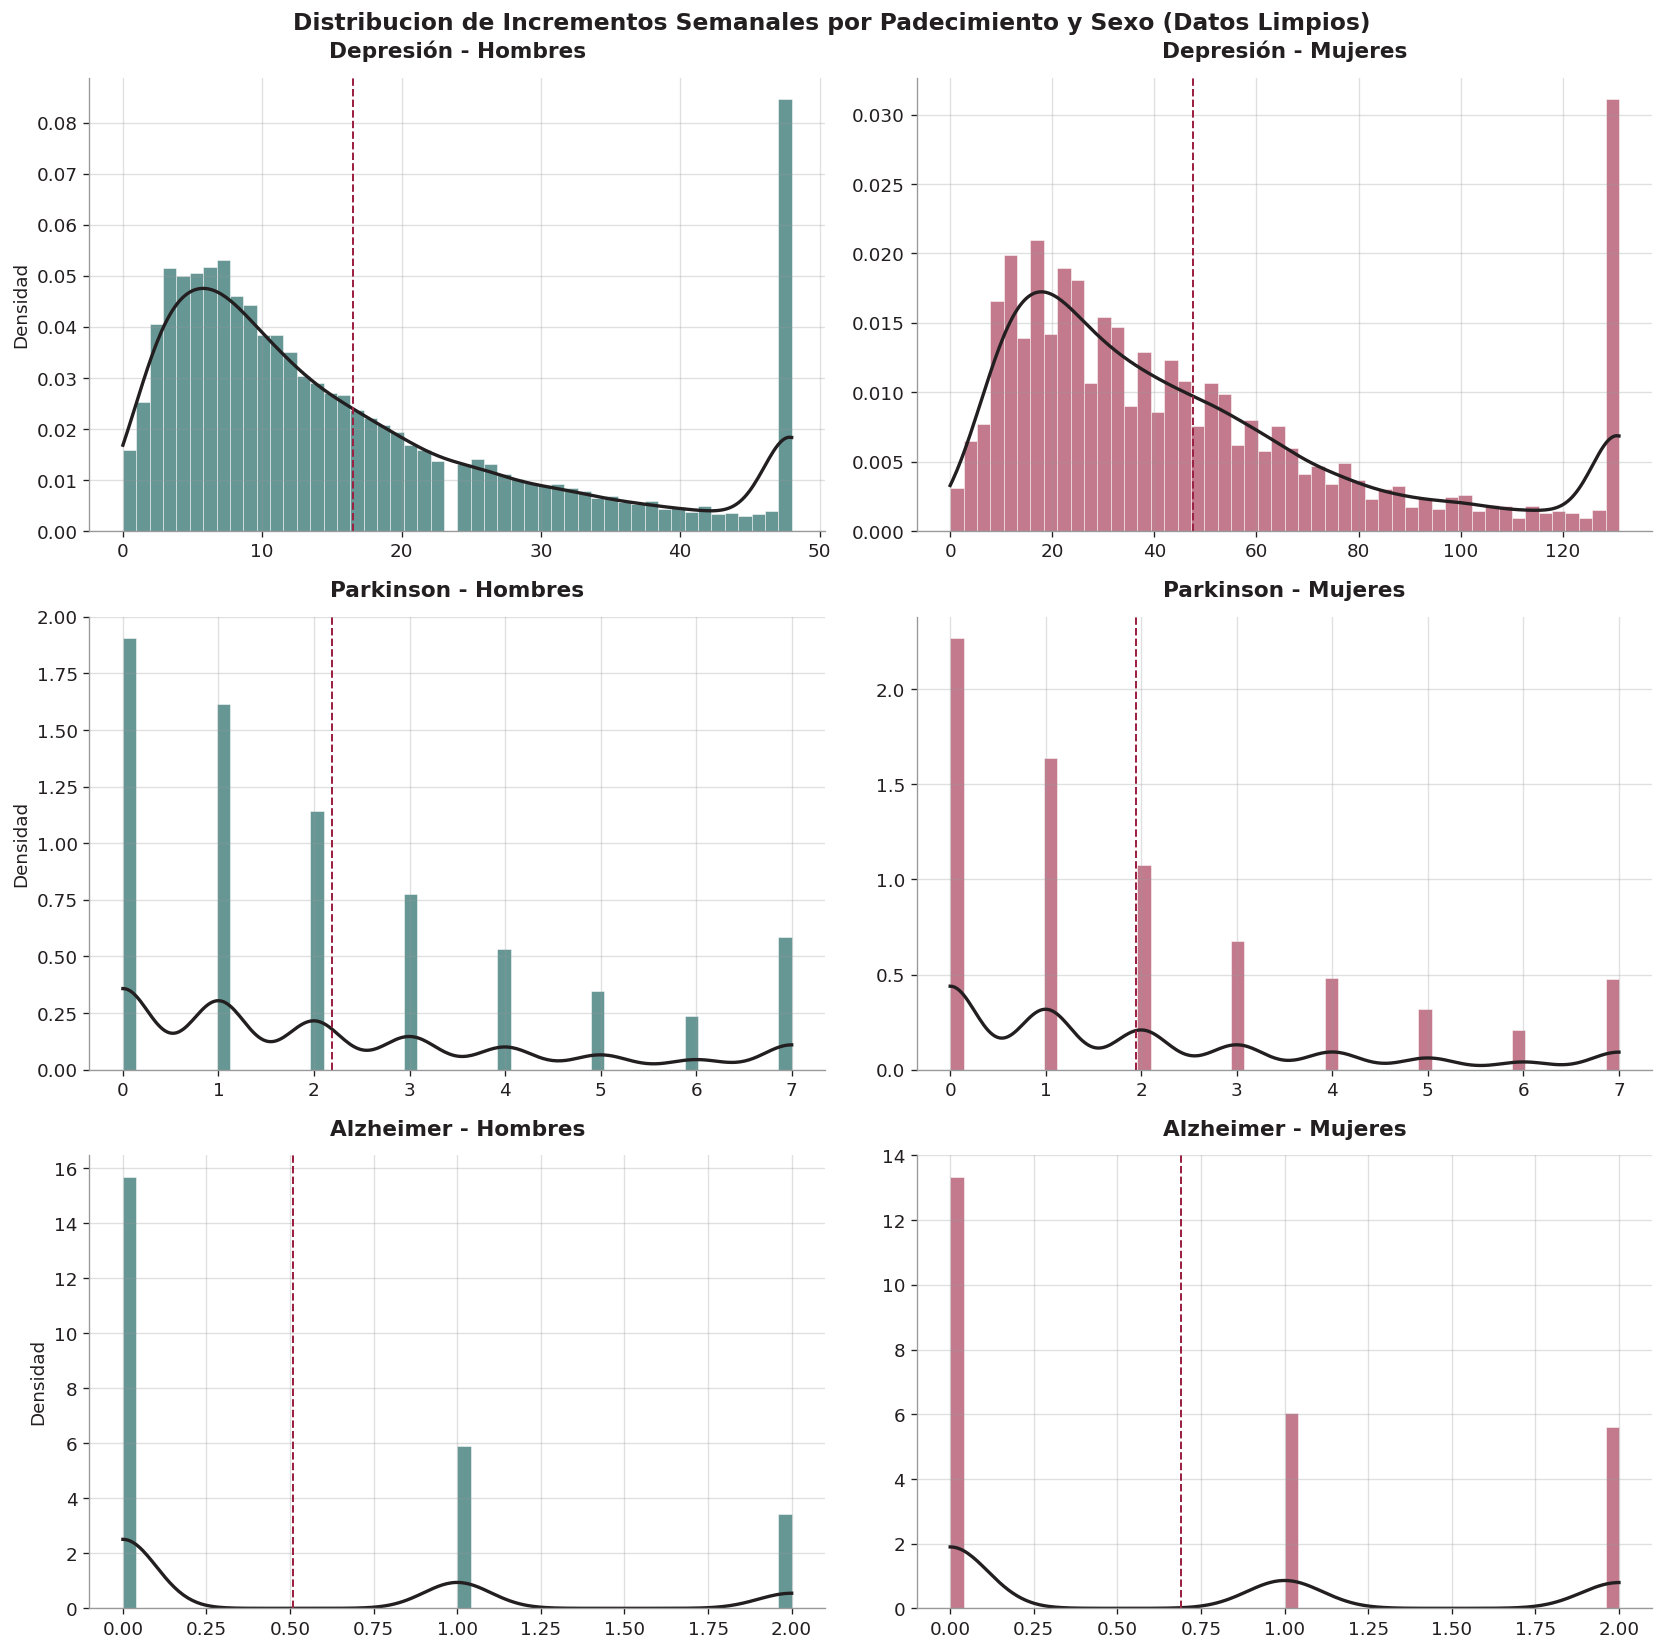

-> Las distribuciones transformadas son significativamente mas compactas y simetricas.


In [51]:
# =============================================================================
# 11.1 DISTRIBUCION DE INCREMENTOS (DATOS LIMPIOS)
# =============================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for i, pad in enumerate(PADECIMIENTOS):
    df_c = dfs_clean[pad]
    for j, (col, sexo) in enumerate([("Incrementos_hombres", "Hombres"),
                                      ("Incrementos_mujeres", "Mujeres")]):
        ax = axes[i][j]
        datos = df_c[col].dropna()
        ax.hist(datos, bins=50, density=True, alpha=0.6,
                color=PALETTE_SEXO[sexo], edgecolor="white", linewidth=0.5)
        try:
            if datos.std() > 0:
                kde = gaussian_kde(datos)
                x_vals = np.linspace(datos.min(), datos.max(), 300)
                ax.plot(x_vals, kde(x_vals), color=IMSS_COLORS["neutral_black"], linewidth=2)
        except Exception:
            pass
        ax.axvline(datos.mean(), color=IMSS_COLORS["burgundy"], linestyle="--", linewidth=1.2)
        format_axis(ax, titulo=f"{pad} - {sexo}", ylabel="Densidad" if j == 0 else "")

fig.suptitle("Distribucion de Incrementos Semanales por Padecimiento y Sexo (Datos Limpios)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "17_incrementos_limpios")
plt.show()

print("-> Las distribuciones transformadas son significativamente mas compactas y simetricas.")

## 11.2 Distribución por Entidad (Post-limpieza)

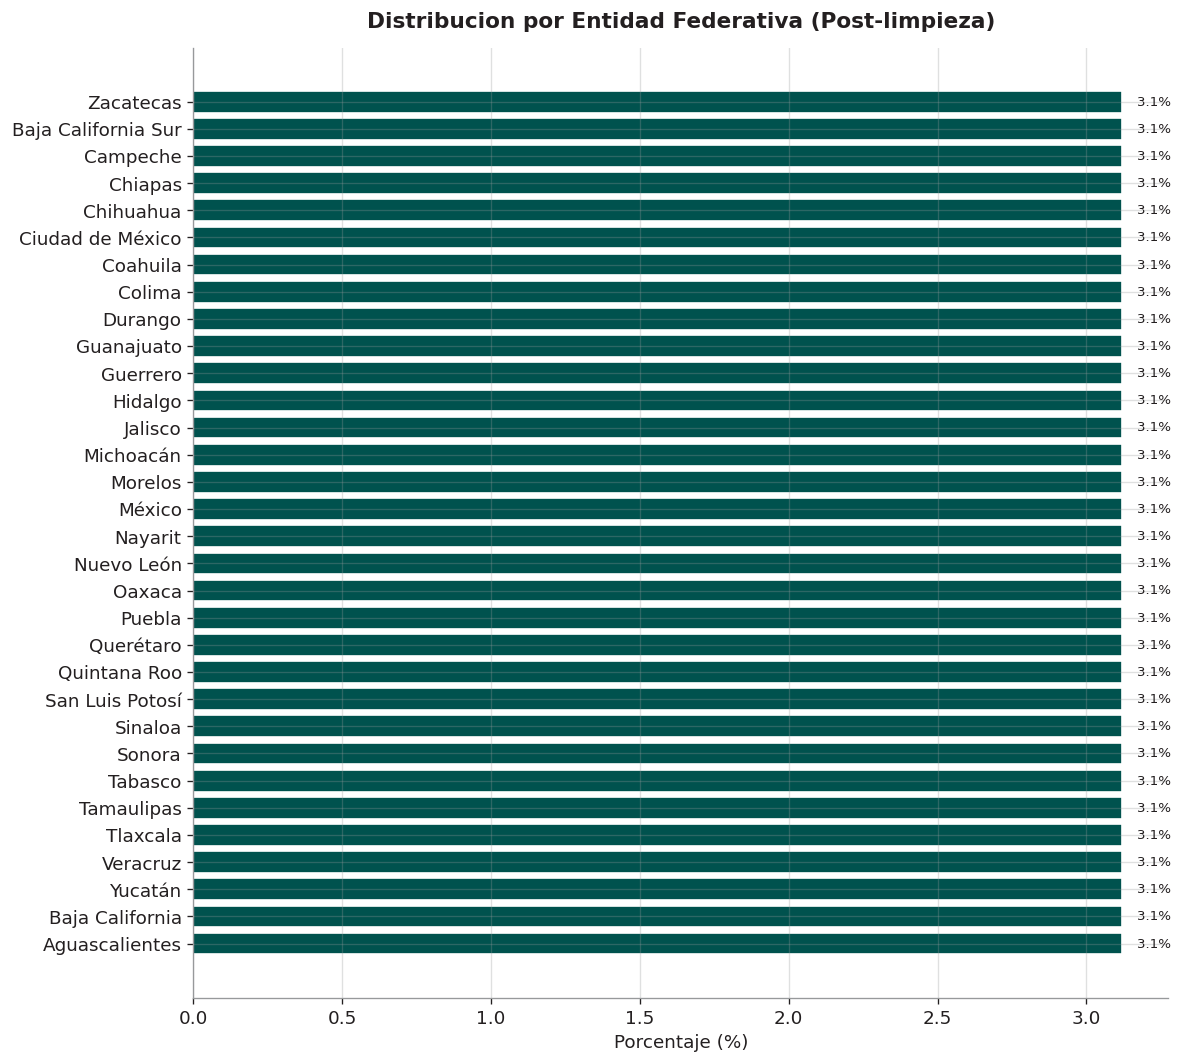

-> Tras unificar D.F. en Ciudad de Mexico: 32 entidades.


In [ ]:
# =============================================================================
# 11.2 DISTRIBUCION POR ENTIDAD DESPUES DE LIMPIEZA
# =============================================================================
df_ref = dfs_clean["Depresion"] if "Depresion" in dfs_clean else dfs_clean[PADECIMIENTOS[0]]

fig, ax = plt.subplots(figsize=(10, 9))
pct_entidad_clean = (df_ref["Entidad"].value_counts(normalize=True) * 100).round(2)
ax.barh(pct_entidad_clean.index, pct_entidad_clean.values,
        color=IMSS_COLORS["teal"], edgecolor="white")
for i, (ent, val) in enumerate(pct_entidad_clean.items()):
    ax.text(val + 0.05, i, f"{val:.1f}%", va="center", fontsize=8)
format_axis(ax, titulo="Distribucion por Entidad Federativa (Post-limpieza)", xlabel="Porcentaje (%)")
fig.tight_layout()
guardar_figura(fig, "18_entidad_limpia")
plt.show()

print(f"-> Tras unificar D.F. en Ciudad de México: {df_ref['Entidad'].nunique()} entidades.")

## 11.3 Matrices de Correlación por Padecimiento

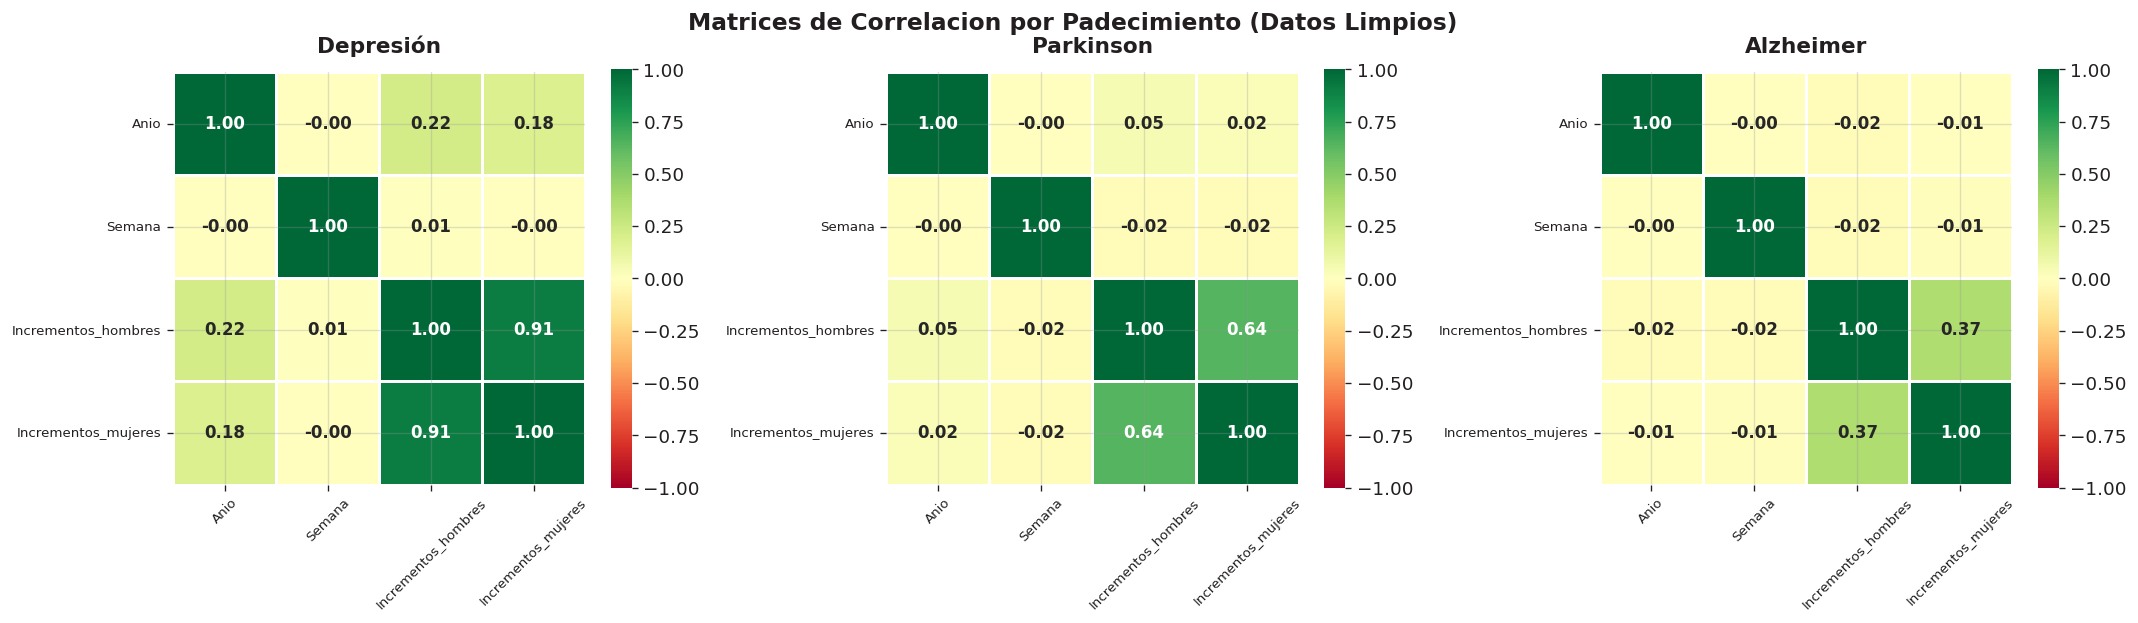

-> Correlaciones reales entre incrementos de hombres y mujeres:
   Alzheimer: debil a moderada
   Parkinson: moderada
   Depresion: fuerte (sincronia marcada entre sexos)


In [53]:
# =============================================================================
# 11.3 CORRELACIONES POR PADECIMIENTO (DATOS LIMPIOS)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, pad in enumerate(PADECIMIENTOS):
    ax = axes[i]
    df_c = dfs_clean[pad]
    cols_num_clean = ["Incrementos_hombres", "Incrementos_mujeres"]
    extra_cols = [c for c in ["Anio", "Semana"] if c in df_c.columns]
    cols_corr = extra_cols + cols_num_clean
    corr_clean = df_c[cols_corr].corr()
    sns.heatmap(
        corr_clean, annot=True, fmt=".2f", cmap="RdYlGn",
        center=0, vmin=-1, vmax=1, square=True, linewidths=0.8,
        annot_kws={"size": 10, "fontweight": "bold"}, ax=ax
    )
    format_axis(ax, titulo=pad)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Matrices de Correlacion por Padecimiento (Datos Limpios)", fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "19_correlacion_limpia")
plt.show()

print("-> Correlaciones reales entre incrementos de hombres y mujeres:")
print("   Alzheimer: debil a moderada")
print("   Parkinson: moderada")
print("   Depresion: fuerte (sincronia marcada entre sexos)")

## 11.4 Violin Plots — Datos Limpios

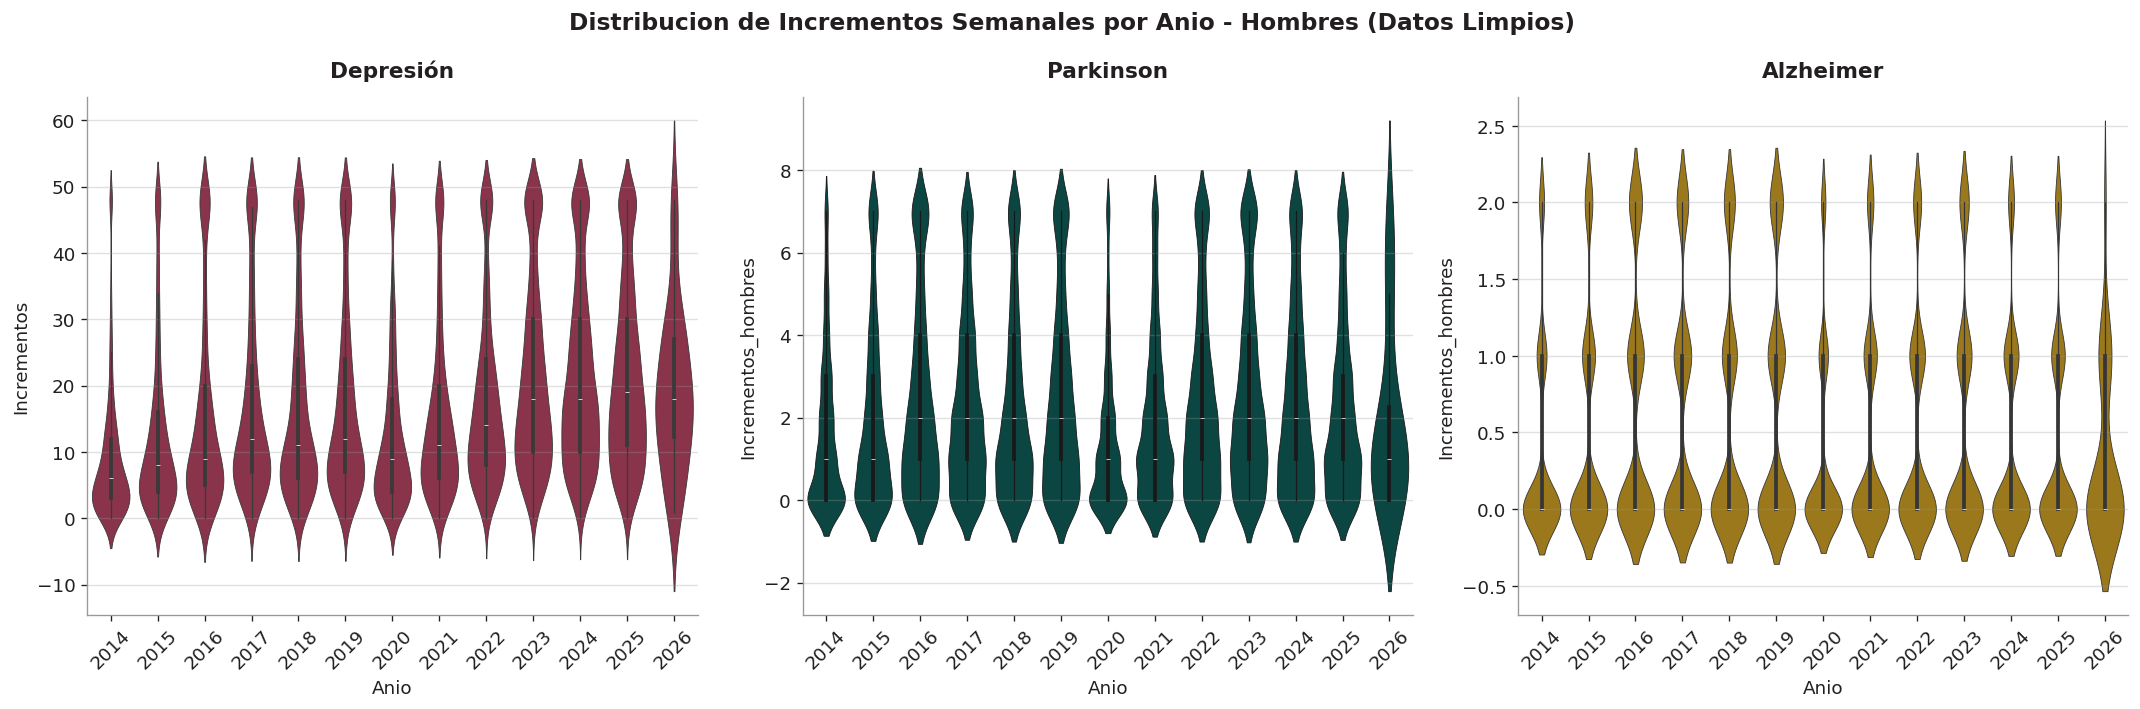

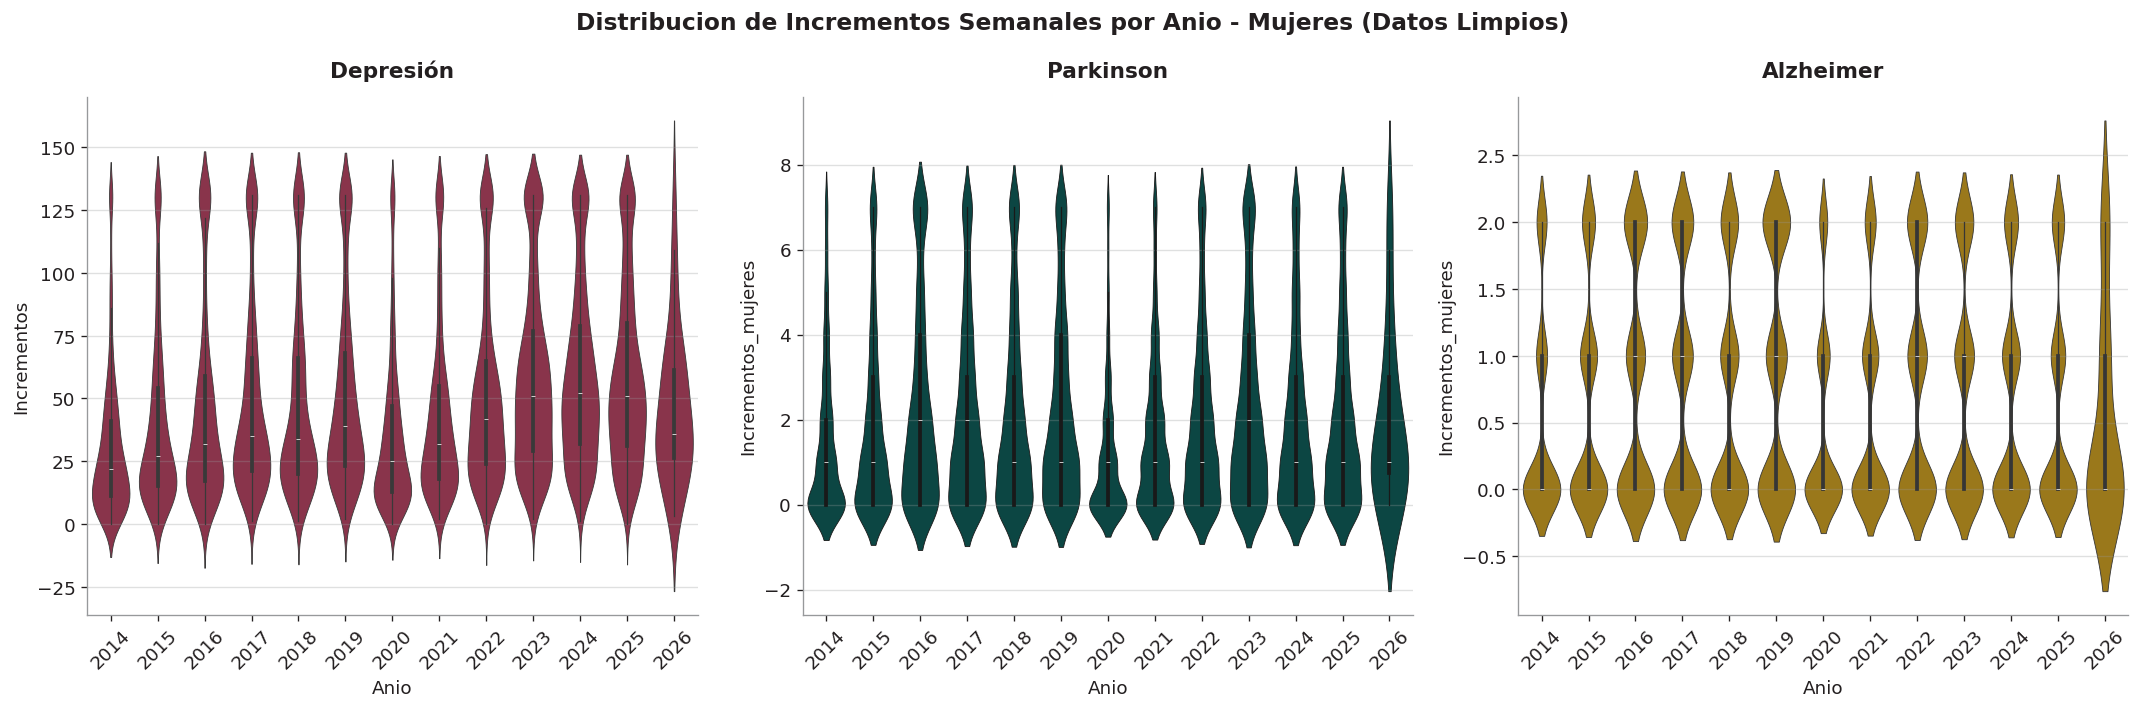

In [54]:
# =============================================================================
# 11.4 VIOLIN PLOTS (DATOS LIMPIOS)
# =============================================================================
for sexo, col_incr in [("Hombres", "Incrementos_hombres"), ("Mujeres", "Incrementos_mujeres")]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i, pad in enumerate(PADECIMIENTOS):
        ax = axes[i]
        df_c = dfs_clean[pad]
        if col_incr not in df_c.columns:
            continue
        sns.violinplot(
            x="Anio", y=col_incr, data=df_c,
            palette=[PALETTE_PADECIMIENTO[pad]] * df_c["Anio"].nunique(),
            inner="box", ax=ax, linewidth=0.5, saturation=0.7
        )
        format_axis(ax, titulo=pad, xlabel="", ylabel="Incrementos" if i == 0 else "", rotation_x=45)
    fig.suptitle(f"Distribucion de Incrementos Semanales por Anio - {sexo} (Datos Limpios)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    guardar_figura(fig, f"20_violins_limpios_{sexo.lower()}")
    plt.show()

## 11.5 Series de Tiempo — Datos Limpios

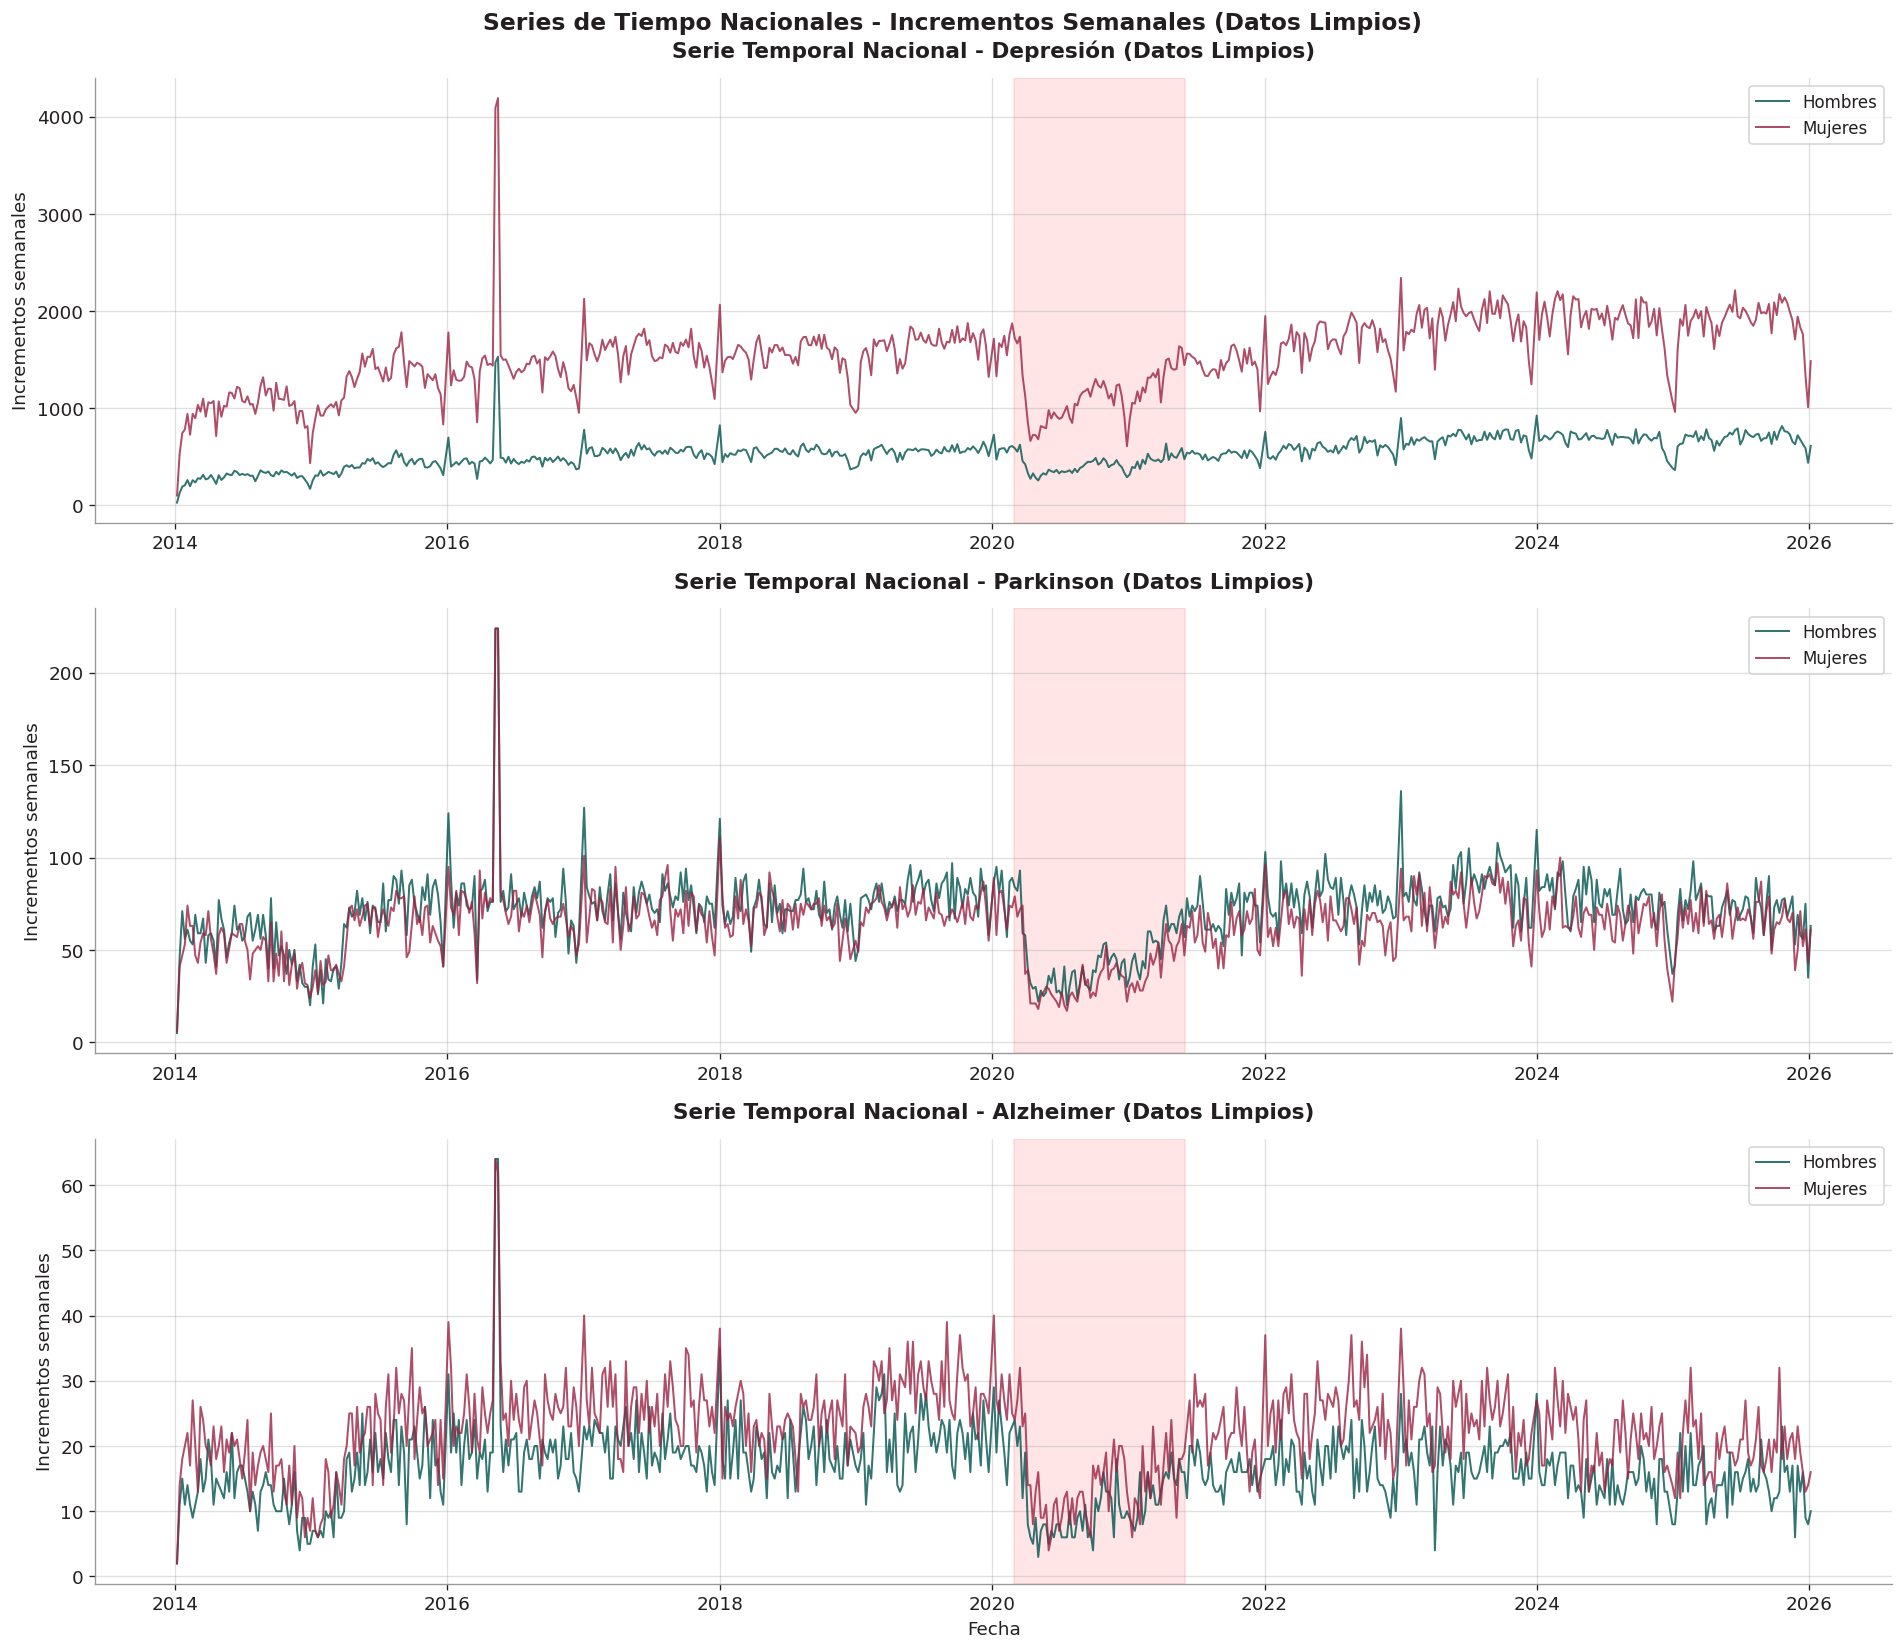

-> Series temporales coherentes tras el preprocesamiento.
   Se identifica posible afectacion durante COVID-19 (2020-2021).


In [55]:
# =============================================================================
# 11.5 SERIES DE TIEMPO NACIONALES (DATOS LIMPIOS)
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for i, pad in enumerate(PADECIMIENTOS):
    ax = axes[i]
    df_c = dfs_clean[pad].dropna(subset=["Fecha"])

    nacional = df_c.groupby("Fecha")[["Incrementos_hombres", "Incrementos_mujeres"]].sum()
    nacional = nacional.sort_index()

    ax.plot(nacional.index, nacional["Incrementos_hombres"],
            linewidth=1.2, alpha=0.8, color=PALETTE_SEXO["Hombres"], label="Hombres")
    ax.plot(nacional.index, nacional["Incrementos_mujeres"],
            linewidth=1.2, alpha=0.8, color=PALETTE_SEXO["Mujeres"], label="Mujeres")

    format_axis(ax, titulo=f"Serie Temporal Nacional - {pad} (Datos Limpios)",
                ylabel="Incrementos semanales")
    ax.legend(fontsize=10)

    # Marcar zona COVID
    try:
        covid_start = pd.Timestamp("2020-03-01")
        covid_end = pd.Timestamp("2021-06-01")
        ax.axvspan(covid_start, covid_end, alpha=0.1, color="red")
    except Exception:
        pass

axes[-1].set_xlabel("Fecha")
fig.suptitle("Series de Tiempo Nacionales - Incrementos Semanales (Datos Limpios)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
guardar_figura(fig, "21_series_temporales_limpias")
plt.show()

print("-> Series temporales coherentes tras el preprocesamiento.")
print("   Se identifica posible afectacion durante COVID-19 (2020-2021).")

## 11.6 Valores Únicos Post-procesamiento

In [56]:
# =============================================================================
# 11.6 VALORES UNICOS DESPUES DE LIMPIEZA
# =============================================================================
for pad in PADECIMIENTOS:
    df_c = dfs_clean[pad]
    print(f"\n{'='*50}")
    print(f"  Valores unicos - {pad}")
    print(f"{'='*50}")
    display(tabla_valores_unicos(df_c).style.set_caption(f"Valores unicos: {pad}"))


  Valores unicos - Depresión


,Valores unicos,Tipo
Fecha,618,datetime64[ns]
Incrementos_mujeres,132,int64
Semana,54,int64
Incrementos_hombres,49,int64
Entidad,32,object
Anio,13,int64
Region,5,object



  Valores unicos - Parkinson


,Valores unicos,Tipo
Fecha,618,datetime64[ns]
Semana,54,int64
Entidad,32,object
Anio,13,int64
Incrementos_hombres,8,int64
Incrementos_mujeres,8,int64
Region,5,object



  Valores unicos - Alzheimer


,Valores unicos,Tipo
Fecha,618,datetime64[ns]
Semana,54,int64
Entidad,32,object
Anio,13,int64
Region,5,object
Incrementos_hombres,3,int64
Incrementos_mujeres,3,int64


---
# 12. Conclusiones y Siguientes Pasos

## 12.1 Síntesis del Análisis

Este avance desarrolló un análisis completo de epidemiología neurológica y de salud mental en México para **Depresión, Parkinson y Alzheimer**, usando información semanal oficial del SINAVE entre 2014 y 2025. El trabajo demuestra que, sin un tratamiento adecuado, los datos acumulados distorsionan la interpretación temporal, y que mediante un pipeline riguroso de limpieza y transformación es posible obtener series de tiempo coherentes, comparables y útiles para modelado.

## 12.2 Pipeline de Datos

El pipeline implementado (`make preprocess`) ejecuta las siguientes etapas:

1. **Extracción**: Identificación y lectura de tablas del Cuadro 17 de los boletines epidemiológicos.
2. **Carga**: Construcción del DataFrame base con ~60,000 registros × 8 columnas.
3. **EDA inicial**: Evaluación de estructura, completitud, distribuciones y anomalías.
4. **Normalización**: Unificación de entidades (Distrito Federal → Ciudad de México).
5. **Filtrado**: Separación por padecimiento para análisis individual.
6. **Eliminación de redundancia**: Remoción de `Acumulado_anio_anterior` y `Casos_semana`.
7. **Corrección temporal**: Ajuste de semanas epidemiológicas.
8. **Transformación**: Conversión de acumulados a incrementos semanales por sexo.
9. **Asignación de fechas**: Estándar ISO de semanas.
10. **Corrección de inconsistencias**: Valores negativos → extrapolación con semanas vecinas.
11. **Tratamiento de outliers**: Imputación basada en IQR.
12. **Feature engineering**: Adición de Región geográfica y Fecha.

## 12.3 Hallazgos Clave

**Calidad de datos:**
- Completitud elevada: solo ~1% de valores nulos (concentrados en `Acumulado_anio_anterior` del primer año).
- 33 entidades detectadas → normalización a 32 (cambio Distrito Federal ↔ Ciudad de México).
- Semana 53 presente en 2020 (consecuencia del calendario epidemiológico).
- Distribución homogénea por entidad (~3.1%) y perfectamente balanceada por padecimiento (33.3%).

**Distribuciones:**
- Variables acumuladas: asimetría positiva extrema, colas largas → inadecuadas para modelado directo.
- Tras transformación a incrementos: distribuciones compactas, simétricas y estadísticamente manejables.

**Tendencias y patrones:**
- **Depresión**: crecimiento sostenido y acelerado post-2020; mujeres con más del doble de casos que hombres; mayor volumen absoluto.
- **Parkinson**: comportamiento estable con picos puntuales (anomalía 2016); incremento gradual desde 2022.
- **Alzheimer**: volatilidad moderada; distribución multi-modal; picos en 2016 y 2019.
- Posible impacto COVID-19 (2020–2021): contracción seguida de repunte.

**Correlaciones:**
- Datos crudos: correlaciones infladas por efecto de acumulación (0.77–0.89).
- Datos limpios: correlaciones reales — Depresión muestra sincronía entre sexos; Alzheimer correlación débil.

## 12.4 Recomendaciones para el Modelado

1. **Modelar por padecimiento**: cada enfermedad tiene dinámica propia.
2. **Usar incrementos semanales** como variable objetivo, no acumulados.
3. **Considerar desagregación por sexo**: la brecha de género en Depresión es significativa.
4. **Evaluar estacionalidad**: patrones semanales identificados que Prophet puede capturar.
5. **Incluir variables exógenas**: región geográfica, período COVID, tendencia poblacional.
6. **Baselines simples primero**: promedios móviles, estacionalidad semanal → luego Prophet.
7. **Validación temporal**: cortes que respeten la estructura cronológica.

## 12.5 Limitaciones

- Los datos provienen de un sistema de vigilancia pasiva (posible subregistro).
- La transformación a incrementos puede introducir sensibilidad a errores de captura acumulada.
- El tratamiento de outliers con IQR puede suavizar picos epidemiológicos legítimos.
- Datos de 2026 limitados a semana 1 (representan el cierre estadístico de 2025).
- No se dispone de variables socioeconómicas, demográficas o de infraestructura sanitaria.

## 12.6 Reflexiones del Equipo

> **Juan Carlos Pérez** — *"Para mí, este avance deja muy clara la importancia de realmente ver los datos antes de intentar sacar conclusiones. No basta con cargarlos y correr análisis automáticos; es necesario entender qué representan, cómo fueron construidos y en qué puntos pueden engañar."*

> **Javier Rebull** — *"En esta etapa nos ayudó mucho enfocarnos en la reproducibilidad del código y en la estructura del proyecto. La calidad del análisis depende directamente de la calidad y trazabilidad del procesamiento previo, más incluso que de la complejidad de los modelos que se puedan aplicar después."*

> **Luis Sánchez** — *"La extracción de datos fue un primer paso esencial, pero este avance marca el punto en el que la información empieza a cobrar sentido. Se siente como el momento en que todas las piezas comienzan a conectarse y el proyecto entra en una fase más analítica y propositiva."*

---
## Referencias

- Alegría, M., et al. (2018). *Social determinants of mental health*. Social Psychiatry and Psychiatric Epidemiology.
- CONEVAL. (2020). *Índices de marginación por entidad federativa y municipio*.
- Elliott, P., & Wartenberg, D. (2004). *Spatial epidemiology*. Environmental Health Perspectives, 112(9).
- INEGI. Áreas geográficas e indicadores territoriales.
- OMS. (2022). *Mental health: Strengthening our response*.
- OPS. (2021). *La salud mental en la región de las Américas*.
- Pérez-Hernández, R. *Enfermedades neurológicas y trastornos mentales en México 2014–2024*.
- Secretaría de Salud. *Boletín Epidemiológico: SINAVE*.
- Visengeriyeva, L., et al. (2023). *CRISP-ML(Q). The ML lifecycle process*. INNOQ.
- WHO. (2022). *World mental health report: Transforming mental health for all*.
- WHO. (2025). *ICD-11 2025 update*.